# Kōura two-method occupancy analysis — Lake Rotoiti stone-pile BACI

# Setup

In [ ]:
library(brms)


Loading required package: Rcpp

Loading 'brms' package (version 2.23.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: 'brms'

The following object is masked from 'package:stats':

    ar

This is cmdstanr version 0.9.0

...

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'tidybayes'

The following objects are masked from 'package:brms':

    dstudent_t, pstudent_t, qstudent_t, rstudent_t

This is posterior version 1.7.0

Attaching package: 'posterior'

The following objects are masked from 'package:stats':

    mad, sd, var

The following objects are masked from 'package:base':

    %in%, match

This is bayesplot version 1.15.0
- Online documentation and vignettes at mc-stan.org/bayesplot
- bayesplot theme set to bayesplot::theme_default()
   * Does _not_ affect other ggplot2 plots
   * See ?bayesplot_theme_set for details on theme setting

Attaching package: 'bayesplot'

The following object is masked from 'package:posterior':

    rhat

The following object is masked from 'package:brms':

    rhat

# A tibble: 7 × 4
  round period season  year
  <int> <fct>  <fct>  <dbl>
1     0 Before Summer     1
2     1 After  Autumn     1
3     2 After  Winter     1
4     3 After  Spring     1
5     4 After  Summer     2
6     5 After  Autumn     2
7     6 After  Winter     2

# Custom two-method occupancy family

Two detection methods deployed at every site every round:

- **Method A** — Box traps (~32 % detection probability)
- **Method B** — Fyke nets (~63 % detection probability)

The custom brms/Stan family marginalises the latent occupancy state *z* over both methods jointly, and tolerates partial missingness (one trap lost to storms) via four `vint()` helper columns per occasion: `yA_obs`, `yB_obs` (trap retrieved?), `yA`, `yB` (kōura detected?).

In [ ]:
stan_funs_occ <- "
  real occ2_lpmf(int y, real psi, real pA, real pB,
                  int yA_obs, int yB_obs, int yA, int yB) {
    real ll_given_occ = 0;
    int any_detect = 0;

    if (yA_obs == 1) {
      ll_given_occ += yA * log(pA) + (1 - yA) * log1m(pA);
      if (yA == 1) any_detect = 1;
    }
    if (yB_obs == 1) {
      ll_given_occ += yB * log(pB) + (1 - yB) * log1m(pB);
      if (yB == 1) any_detect = 1;
    }

    if (any_detect == 1) {
      return log(psi) + ll_given_occ;
    } else {
      return log_sum_exp(log(psi) + ll_given_occ, log1m(psi));
    }
  }
"

stanvars_occ <- brms::stanvar(scode = stan_funs_occ, block = "functions")

# brms custom family — dpars must start with "mu" (brms >= 2.21)
# mu maps to psi (true occupancy); pA and pB are detection submodels
# vars must use brms internal vint names matching vint() order in formula
occ2 <- custom_family(
  name  = "occ2",
  dpars = c("mu", "pA", "pB"),
  links = c("logit", "logit", "logit"),
  lb    = c(0, 0, 0),
  ub    = c(1, 1, 1),
  type  = "int",
  vars  = c("vint1[n]", "vint2[n]", "vint3[n]", "vint4[n]")
)

log_lik_occ2 <- function(i, prep) {
  psi    <- brms::get_dpar(prep, "mu", i = i)
  pA     <- brms::get_dpar(prep, "pA", i = i)
  pB     <- brms::get_dpar(prep, "pB", i = i)
  yA_obs <- prep$data$vint1[i]; yB_obs <- prep$data$vint2[i]
  yA     <- prep$data$vint3[i]; yB     <- prep$data$vint4[i]
  ll_given_occ <- 0; any_detect <- 0
  if (yA_obs == 1) {
    ll_given_occ <- ll_given_occ + yA * log(pA) + (1 - yA) * log1p(-pA)
    if (yA == 1) any_detect <- 1
  }
  if (yB_obs == 1) {
    ll_given_occ <- ll_given_occ + yB * log(pB) + (1 - yB) * log1p(-pB)
    if (yB == 1) any_detect <- 1
  }
  if (any_detect == 1) log(psi) + ll_given_occ
  else log(psi * exp(ll_given_occ) + (1 - psi))
}

posterior_predict_occ2 <- function(i, prep, ...) {
  psi    <- brms::get_dpar(prep, "mu", i = i)
  pA     <- brms::get_dpar(prep, "pA", i = i)
  pB     <- brms::get_dpar(prep, "pB", i = i)
  yA_obs <- prep$data$vint1[i]; yB_obs <- prep$data$vint2[i]
  z      <- rbinom(length(psi), 1, psi)
  yA_sim <- ifelse(yA_obs == 1, rbinom(length(psi), 1, z * pA), NA_integer_)
  yB_sim <- ifelse(yB_obs == 1, rbinom(length(psi), 1, z * pB), NA_integer_)
  rowSums(cbind(yA_sim, yB_sim), na.rm = TRUE)
}

# posterior_epred returns psi (true occupancy), not detection-weighted catch
posterior_epred_occ2 <- function(prep) {
  brms::get_dpar(prep, "mu")
}

cat("Custom family 'occ2' defined.\n")


Custom family 'occ2' defined.

# Import and prepare data

In [ ]:
model_data_path <- file.path(der_dir, "model_data.rds")

if (!file.exists(model_data_path)) {

  combined <- readr::read_csv(file.path("data", "derived", "Combined_data.csv"),
                               show_col_types = FALSE)
  fish     <- readr::read_csv(file.path("data", "derived", "Fish_data.csv"),
                               show_col_types = FALSE)

  backbone <- combined |>
    dplyr::transmute(
      site_id            = as.integer(site_id),
      round              = as.integer(monitoring),
      monitoring_id      = monitoring_id,
      location_type      = dplyr::case_when(
        Site_type_detail == "Stone_pile"  ~ "Stone_pile",
        Site_type_detail == "Control"     ~ "Control",
        Site_type_detail == "Reference_1" ~ "Reference1",
        Site_type_detail == "Reference_2" ~ "Reference2",
        TRUE                              ~ NA_character_),
      block              = dplyr::case_when(
        Site_type_detail %in% c("Stone_pile", "Control")      ~ "Impact",
        Site_type_detail %in% c("Reference_1", "Reference_2") ~ "Reference",
        TRUE                                                    ~ NA_character_),
      temperature        = as.numeric(Temperature),
      monitoring_quality = as.character(monitoring_quality),
      pair_id            = pair_id
    ) |>
    dplyr::filter(!is.na(location_type))

  # One row per kōura individual → collapse to presence per site×round×method
  koura_by_method <- fish |>
    dplyr::filter(species == "Kōura") |>
    dplyr::group_by(site_id, monitoring_id, net_type) |>
    dplyr::summarise(detected = 1L, .groups = "drop") |>
    dplyr::mutate(site_id = as.integer(site_id))

  # Cross all valid site×round combinations with both methods; fill 0 for no-catch
  all_combos <- backbone |>
    dplyr::select(site_id, monitoring_id) |>
    tidyr::crossing(net_type = c("Box", "Fyke"))

  detection_wide <- all_combos |>
    dplyr::left_join(
      koura_by_method |> dplyr::select(site_id, monitoring_id, net_type, detected),
      by = c("site_id", "monitoring_id", "net_type")) |>
    dplyr::mutate(detected = tidyr::replace_na(detected, 0L)) |>
    tidyr::pivot_wider(names_from = net_type, values_from = detected) |>
    dplyr::rename(yA = Box, yB = Fyke)

  real_data <- backbone |>
    dplyr::left_join(detection_wide, by = c("site_id", "monitoring_id")) |>
    dplyr::mutate(
      # monitoring_quality == "complete" → both traps usable
      usable = monitoring_quality == "complete",
      yA_obs = as.integer(usable),
      yB_obs = as.integer(usable),
      yA     = dplyr::if_else(usable, yA, NA_integer_),
      yB     = dplyr::if_else(usable, yB, NA_integer_)
    ) |>
    dplyr::filter(!(yA_obs == 0 & yB_obs == 0)) |>   # drop zero-info occasions
    dplyr::left_join(round_lookup, by = "round") |>
    dplyr::mutate(
      location_type = factor(location_type, levels = location_levels),
      block         = factor(block, levels = block_levels),
      location_id   = paste(site_id, location_type, sep = "_"),
      temp_z        = as.numeric(scale(temperature))  # global standardisation
    ) |>
    dplyr::select(site_id, block, location_type, location_id, round,
                  period, season, year, temperature, temp_z,
                  yA_obs, yB_obs, yA, yB, pair_id, monitoring_quality)

  # Stan requires no NAs: replace NA detection with 0 (yA_obs/yB_obs flags
  # tell Stan to ignore the value when the trap was lost)
  model_data <- real_data |>
    dplyr::mutate(
      y_dummy = 0L,
      yA = dplyr::if_else(is.na(yA), 0L, yA),
      yB = dplyr::if_else(is.na(yB), 0L, yB)
    )

  # Validation
  stopifnot(
    all(model_data$yA %in% c(0L, 1L)),
    all(model_data$yB %in% c(0L, 1L)),
    all(model_data$round %in% 0:6),
    all(model_data$yA_obs == 1 | model_data$yB_obs == 1)
  )

  saveRDS(model_data, model_data_path)
  cat("Imported and saved:", nrow(model_data), "occasions\n")

} else {
  model_data <- readRDS(model_data_path)
  cat("Loaded cached model data:", nrow(model_data), "occasions\n")
}


Loaded cached model data: 128 occasions


Occasions by location × period × season:

# A tibble: 20 × 4
   location_type period season     n
   <fct>         <fct>  <fct>  <int>
 1 Control       Before Summer     5
 2 Control       After  Summer     5
 3 Control       After  Autumn     8
 4 Control       After  Winter     8
 5 Control       After  Spring     4
 6 Stone_pile    Before Summer     5
 7 Stone_pile    After  Summer     5
 8 Stone_pile    After  Autumn    10
 9 Stone_pile    After  Winter     8
10 Stone_pile    After  Spring     4
11 Reference1    Before Summer     5
12 Reference1    After  Summer     5
13 Reference1    After  Autumn     9
14 Reference1    After  Winter     9
15 Reference1    After  Spring     5
16 Reference2    Before Summer     5
17 Reference2    After  Summer     5
18 Reference2    After  Autumn     9
19 Reference2    After  Winter     9
20 Reference2    After  Spring     5


Kōura detection rates by method:

  Box trap (yA): 0.32 

  Fyke net (yB): 0.633 

# Priors

Weakly informative normal(0, 1.5) priors on log-odds scale for fixed effects (allows ±3 units ≈ occupancy/detection probability ranging ~0.05–0.95). Normal(0, 1) on random-effect SDs.

In [ ]:
priors_occ <- c(
  prior(normal(0, 1.5), class = "b"),
  prior(normal(0, 1.5), class = "b", dpar = "pA"),
  prior(normal(0, 1.5), class = "b", dpar = "pB"),
  prior(normal(0, 1),   class = "sd"),
  prior(normal(0, 1),   class = "sd", dpar = "pA"),
  prior(normal(0, 1),   class = "sd", dpar = "pB")
)


# Model 1: Full model (all seasons)

Primary model using all 128 occasions. Tests `location_type × period × season` interaction. Provides whole-study headline occupancy estimates and uses the full data to estimate variance components (site random effects, detection–temperature slope) most precisely.

In [ ]:
full_path <- file.path(der_dir, "fit_full.rds")

if (!file.exists(full_path)) {

  bf_full <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period * season + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_full <- brm(
    bf_full,
    data     = model_data,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.97, max_treedepth = 13)
  )

  saveRDS(fit_full, full_path)
  cat("Fitted and saved full model.\n")

} else {
  fit_full <- readRDS(full_path)
  cat("Loaded cached full model.\n")
}


Loaded cached full model.

Loading required namespace: rstan

adapt_delta above 0.97 may help. See
http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup

 Family: occ2 
  Links: mu = logit; pA = logit; pB = logit 
Formula: y_dummy | vint(yA_obs, yB_obs, yA, yB) ~ location_type * period * season + (1 | site_id) 
         pA ~ 1 + temp_z + (1 | site_id)
         pB ~ 1 + temp_z + (1 | site_id)
   Data: model_data (Number of observations: 128) 
  Draws: 4 chains, each with iter = 4000; warmup = 1500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~site_id (Number of levels: 20) 
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)        1.92      0.88     0.16     3.46 1.01      786     1644
sd(pA_Intercept)     1.96      0.50     1.11     3.05 1.00     4729     6122
sd(pB_Intercept)     1.15      0.58     0.09     2.33 1.01     1169     3034

Regression Coefficients:
                                                 Estimate Est.Error l-95% CI
Intercept                                            1.94      2.59    -1.18
pA_Intercept                                      


Max Rhat:    1.009885 

Min ESS:     786.0332 

Divergences: 1 

Loading required namespace: rstan

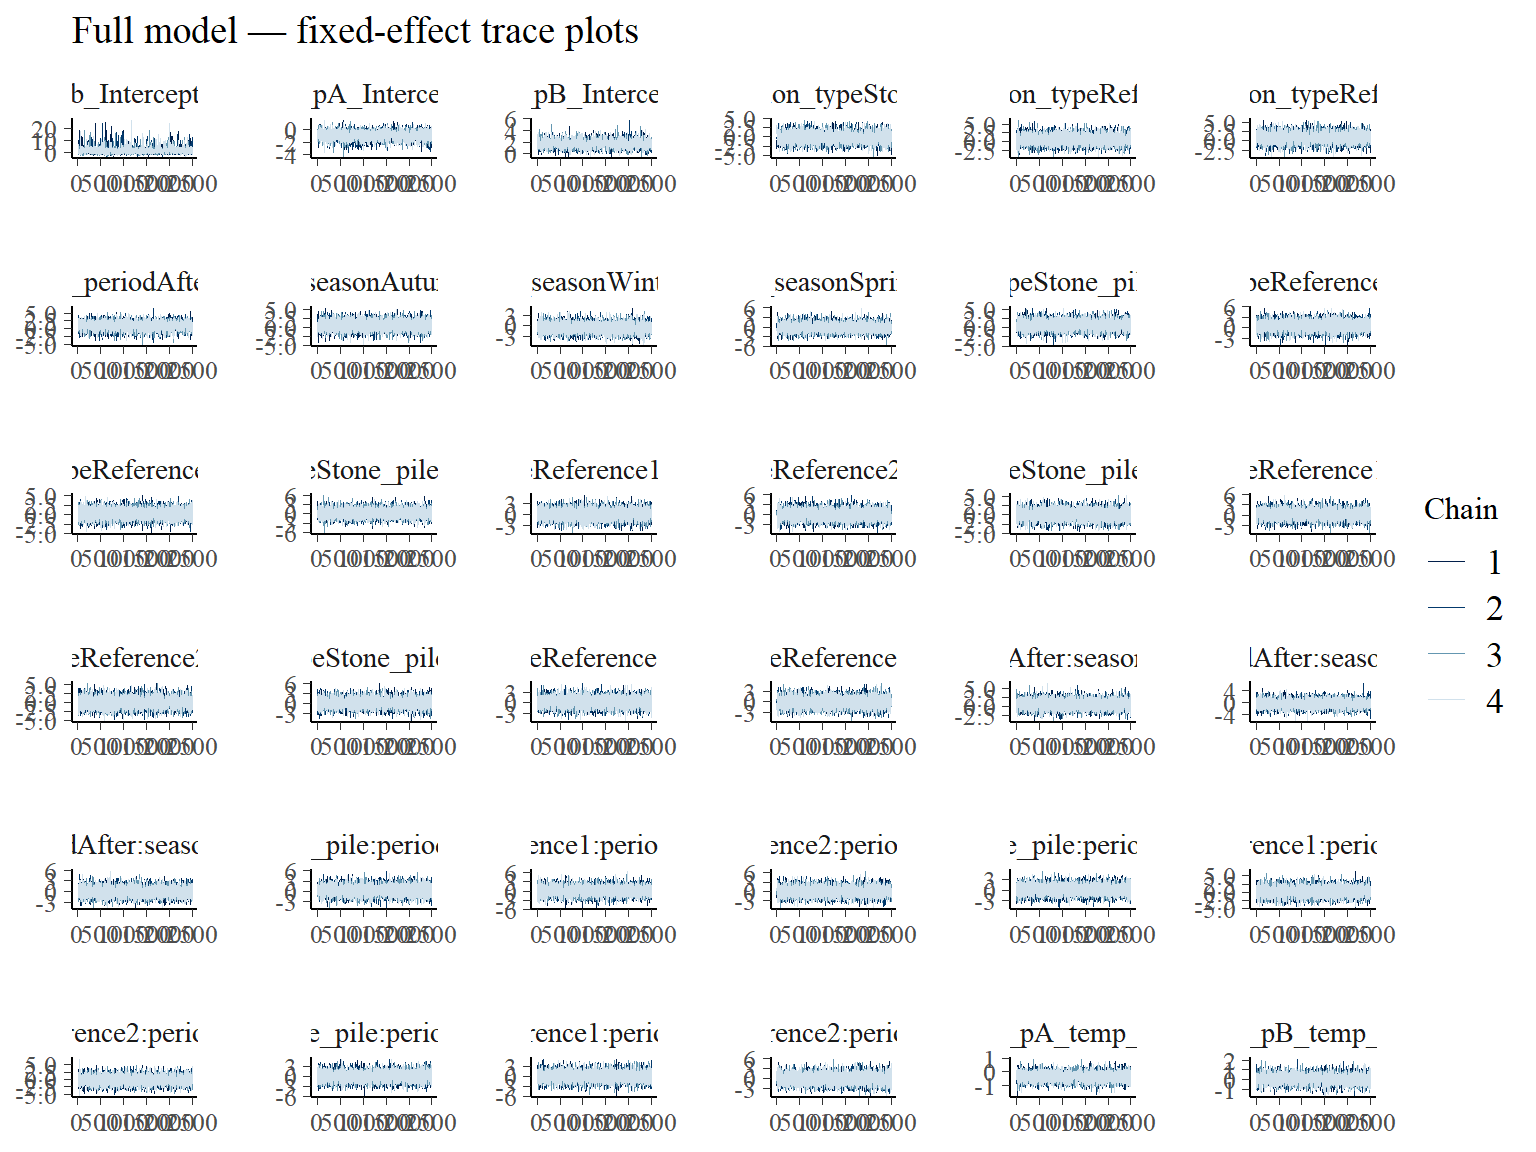

In [ ]:
bayesplot::mcmc_trace(fit_full, regex_pars = "^b_") +
  labs(title = "Full model — fixed-effect trace plots")


# Model 2: Summer-only model

Confirmatory model restricted to Summer rounds (R0 Before, R4 After). Targets the a-priori hypothesis that refuge value is greatest in summer when catfish pressure and thermal stratification are highest. Treated as a robustness check on the summer cells of the full model, not a replacement for it.

In [ ]:
summer_path <- file.path(der_dir, "fit_summer.rds")
summer_data <- model_data |> dplyr::filter(season == "Summer")

cat("Summer subset:", nrow(summer_data), "occasions\n")


Summer subset: 40 occasions

# A tibble: 8 × 3
  location_type period     n
  <fct>         <fct>  <int>
1 Control       Before     5
2 Control       After      5
3 Stone_pile    Before     5
4 Stone_pile    After      5
5 Reference1    Before     5
6 Reference1    After      5
7 Reference2    Before     5
8 Reference2    After      5

Loaded cached summer model.

adapt_delta above 0.97 may help. See
http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup

 Family: occ2 
  Links: mu = logit; pA = logit; pB = logit 
Formula: y_dummy | vint(yA_obs, yB_obs, yA, yB) ~ location_type * period + (1 | site_id) 
         pA ~ 1 + temp_z + (1 | site_id)
         pB ~ 1 + temp_z + (1 | site_id)
   Data: summer_data (Number of observations: 40) 
  Draws: 4 chains, each with iter = 4000; warmup = 1500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~site_id (Number of levels: 20) 
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)        0.97      0.69     0.05     2.56 1.00     3936     5537
sd(pA_Intercept)     1.98      0.74     0.42     3.46 1.00     3094     1462
sd(pB_Intercept)     1.13      0.69     0.06     2.61 1.00     2655     3052

Regression Coefficients:
                                    Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                               3.15      3.62    -0.73    12.48 1.00
pA_Intercept                           -1.52      1.54   


Max Rhat:    1.00145 

Min ESS:     1544.581 

Divergences: 9 

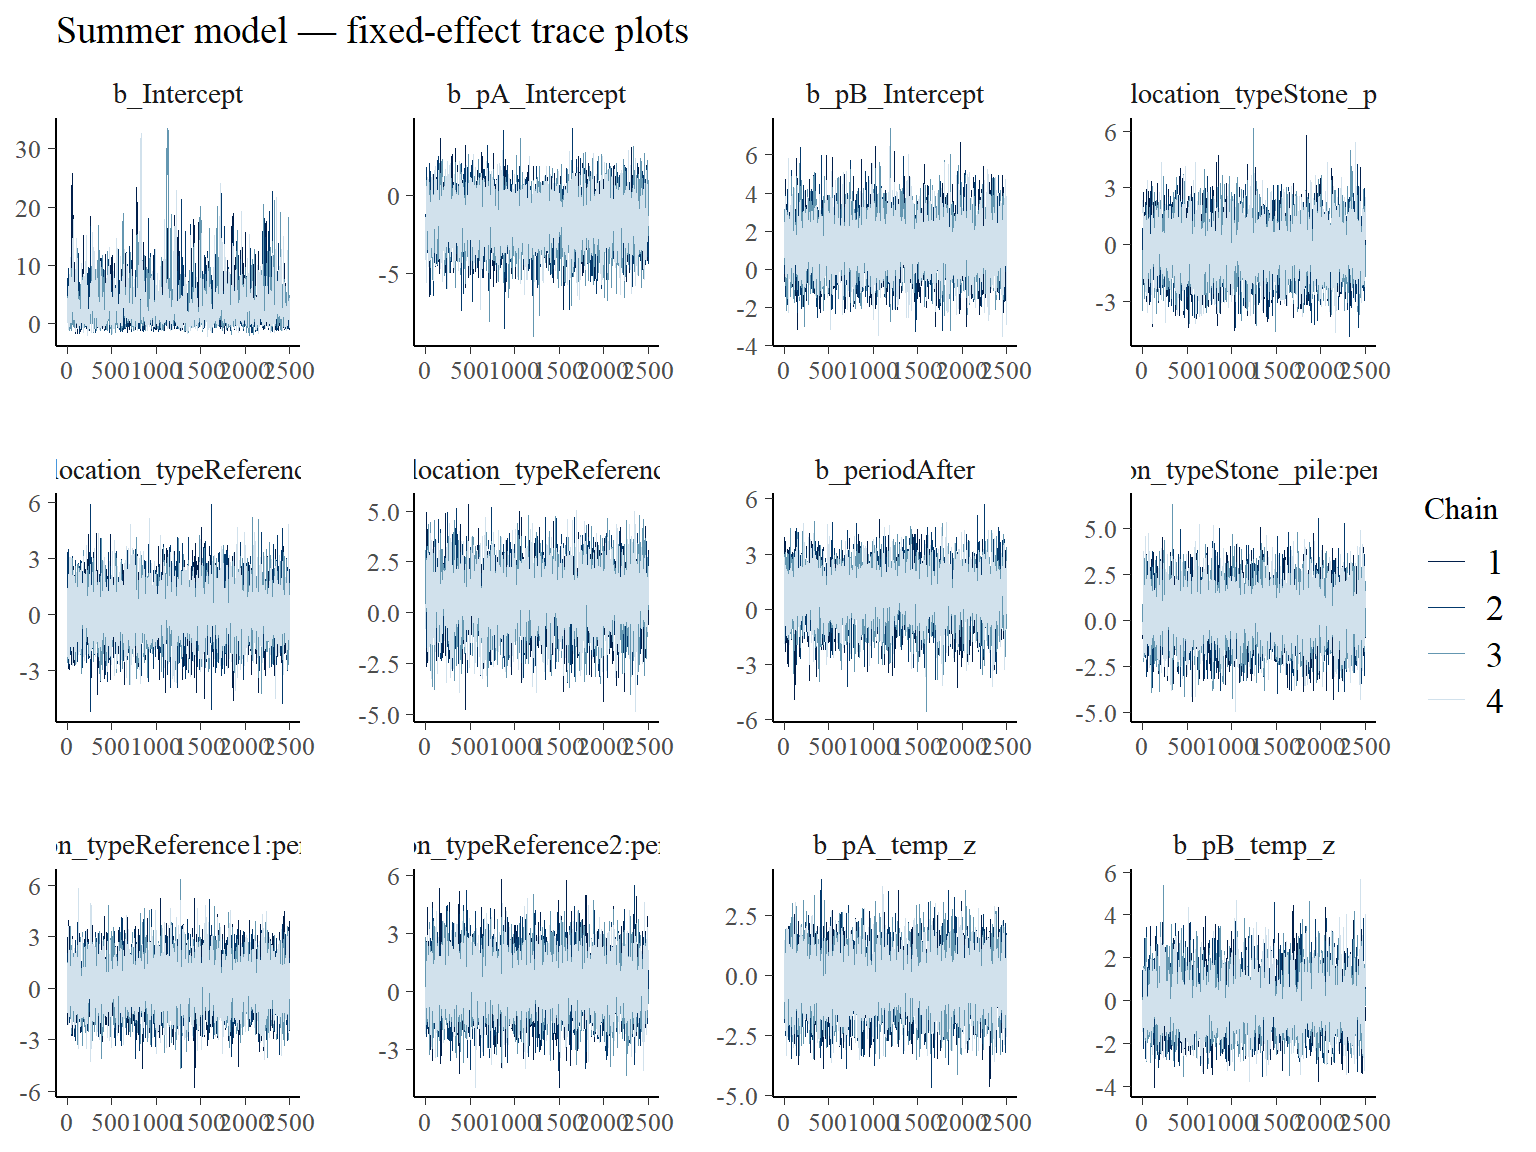

In [ ]:
bayesplot::mcmc_trace(fit_summer, regex_pars = "^b_") +
  labs(title = "Summer model — fixed-effect trace plots")


# Model 3: Warm-season model (Summer + Autumn)

Ecological rationale: thermal stratification in Lake Rotoiti peaks in summer and persists through autumn, compressing kōura into the oxygenated nearshore zone where stone piles sit. Catfish predation pressure is also highest in these two seasons. This model tests the restoration signal in the combined warm season (76 occasions) with more power than summer-only (40 occasions).

Season is included as an additive covariate — not a full three-way interaction — because the data support estimating seasonal baseline differences in occupancy but not the full `location_type × period × season` interaction in this subset.

In [ ]:
warm_path <- file.path(der_dir, "fit_warm.rds")
warm_data <- model_data |>
  dplyr::filter(season %in% c("Summer", "Autumn")) |>
  dplyr::mutate(season = droplevels(season))

cat("Warm subset:", nrow(warm_data), "occasions\n")


Warm subset: 76 occasions

# A tibble: 12 × 4
   location_type period season     n
   <fct>         <fct>  <fct>  <int>
 1 Control       Before Summer     5
 2 Control       After  Summer     5
 3 Control       After  Autumn     8
 4 Stone_pile    Before Summer     5
 5 Stone_pile    After  Summer     5
 6 Stone_pile    After  Autumn    10
 7 Reference1    Before Summer     5
 8 Reference1    After  Summer     5
 9 Reference1    After  Autumn     9
10 Reference2    Before Summer     5
11 Reference2    After  Summer     5
12 Reference2    After  Autumn     9

Loaded cached warm model.

adapt_delta above 0.99 may help. See
http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup

 Family: occ2 
  Links: mu = logit; pA = logit; pB = logit 
Formula: y_dummy | vint(yA_obs, yB_obs, yA, yB) ~ location_type * period + season + (1 | site_id) 
         pA ~ 1 + temp_z + (1 | site_id)
         pB ~ 1 + temp_z + (1 | site_id)
   Data: warm_data (Number of observations: 76) 
  Draws: 4 chains, each with iter = 4000; warmup = 1500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~site_id (Number of levels: 20) 
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)        1.35      0.81     0.07     2.99 1.00     1525     3512
sd(pA_Intercept)     1.91      0.55     0.94     3.06 1.00     5561     4546
sd(pB_Intercept)     1.03      0.65     0.04     2.45 1.00     1842     4045

Regression Coefficients:
                                    Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                               2.87      3.22    -0.67    10.81 1.00
pA_Intercept                           -0.30      


Max Rhat:    1.001612 

Min ESS:     1327.542 

Divergences: 6 

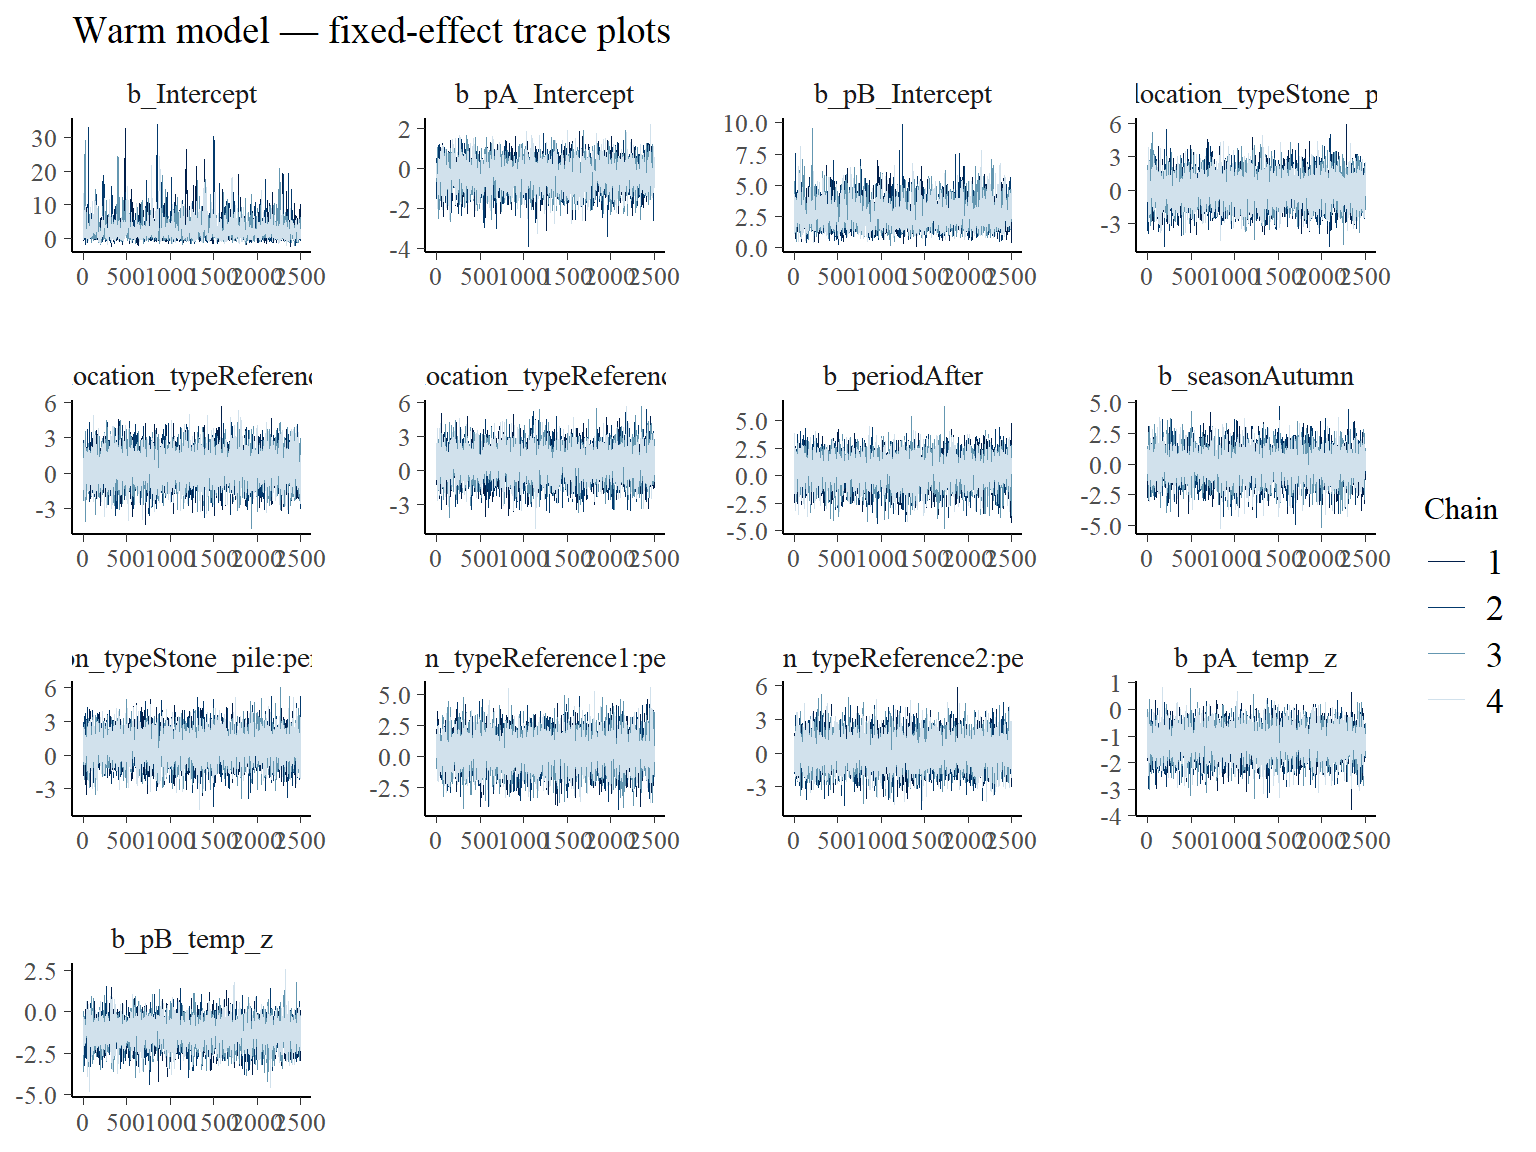

In [ ]:
bayesplot::mcmc_trace(fit_warm, regex_pars = "^b_") +
  labs(title = "Warm model — fixed-effect trace plots")


# Extract posterior contrasts plots

Four contrasts of ecological interest, evaluated in the After period:

1.  **Stone_pile − Control** — did rocks help, relative to the paired control?
2.  **Reference1 − Reference2** — spatial noise floor (how similar are reference sites?)
3.  **Control − Reference (mean)** — how far below reference quality is the control?
4.  **Stone_pile − Reference (mean)** — how close to optimal did stone piles get?

Plus the **BACI double-difference**: `(Stone_pile After−Before) − (Control After−Before)` — the most defensible causal estimate, as it removes any pre-existing gap between site types.

In [ ]:
summarise_draws_vec <- function(x, label) {
  tibble(
    contrast     = label,
    mean         = mean(x),
    median       = median(x),
    lower95      = quantile(x, 0.025),
    upper95      = quantile(x, 0.975),
    p_direction  = mean(x > 0)
  )
}

get_psi_draws <- function(fit, model_data, include_season = TRUE) {
  grid_vars <- if (include_season) {
    model_data |> dplyr::distinct(location_type, period, season)
  } else {
    model_data |> dplyr::distinct(location_type, period)
  }
  newdata <- grid_vars |>
    dplyr::mutate(
      site_id  = model_data$site_id[1],
      temp_z   = 0, yA_obs = 1, yB_obs = 1, yA = 0, yB = 0, y_dummy = 0
    )
  draws <- posterior_epred(fit, newdata = newdata, re_formula = NA, dpar = "mu")
  colnames(draws) <- if (include_season) {
    paste(newdata$location_type, newdata$period, newdata$season, sep = "|")
  } else {
    paste(newdata$location_type, newdata$period, sep = "|")
  }
  list(draws = draws, grid = newdata)
}

build_contrasts <- function(draws, grid, period_val, season_val = NULL) {
  key <- function(loc) {
    if (is.null(season_val)) paste(loc, period_val, sep = "|")
    else paste(loc, period_val, season_val, sep = "|")
  }
  d_add      <- draws[, key("Stone_pile")]
  d_ctrl     <- draws[, key("Control")]
  d_ref1     <- draws[, key("Reference1")]
  d_ref2     <- draws[, key("Reference2")]
  d_ref_mean <- (d_ref1 + d_ref2) / 2
  bind_rows(
    summarise_draws_vec(d_add  - d_ctrl,      "Stone_pile - Control"),
    summarise_draws_vec(d_ref1 - d_ref2,      "Reference1 - Reference2"),
    summarise_draws_vec(d_ctrl - d_ref_mean,  "Control - Reference (mean)"),
    summarise_draws_vec(d_add  - d_ref_mean,  "Stone_pile - Reference (mean)")
  ) |>
    dplyr::mutate(period = period_val,
                  season = if (is.null(season_val)) NA_character_ else season_val)
}

build_baci <- function(draws, include_season, season_val = NULL) {
  key <- function(loc, period) {
    if (include_season) paste(loc, period, season_val, sep = "|")
    else paste(loc, period, sep = "|")
  }
  d <- (draws[, key("Stone_pile", "After")] - draws[, key("Stone_pile", "Before")]) -
       (draws[, key("Control",    "After")] - draws[, key("Control",    "Before")])
  summarise_draws_vec(d, "BACI: (Stone_pile After-Before) - (Control After-Before)") |>
    dplyr::mutate(period = "Before-vs-After",
                  season = if (include_season) season_val else NA_character_)
}

run_contrasts <- function(fit, model_data, model_label, include_season = TRUE) {
  psi_out <- get_psi_draws(fit, model_data, include_season)
  draws   <- psi_out$draws
  grid    <- psi_out$grid

  cell_summary <- tibble(
    location_type = grid$location_type,
    period        = grid$period,
    season        = if (include_season) grid$season else NA
  ) |>
    dplyr::mutate(
      psi_mean = apply(draws, 2, mean),
      psi_lwr  = apply(draws, 2, quantile, 0.025),
      psi_upr  = apply(draws, 2, quantile, 0.975)
    )

  if (include_season) {
    seasons_present      <- unique(grid$season)
    contrasts_after      <- purrr::map_dfr(seasons_present,
                              ~ build_contrasts(draws, grid, "After", .x))
    seasons_with_before  <- grid |>
      dplyr::filter(period == "Before") |> dplyr::pull(season) |> unique()
    baci <- purrr::map_dfr(seasons_with_before,
               ~ build_baci(draws, include_season = TRUE, season_val = .x))
  } else {
    contrasts_after <- build_contrasts(draws, grid, "After")
    baci            <- build_baci(draws, include_season = FALSE)
  }

  contrasts_all <- dplyr::bind_rows(contrasts_after, baci) |>
    dplyr::mutate(model = model_label)

  readr::write_csv(cell_summary,
    file.path(der_dir, paste0(model_label, "_psi_estimates.csv")))
  readr::write_csv(contrasts_all,
    file.path(der_dir, paste0(model_label, "_contrasts.csv")))

  # Shared display helpers — colours and shapes match analysis.qmd
  site_labels  <- c(Stone_pile = "Stone pile", Control = "Control",
                    Reference1 = "Reference 1", Reference2 = "Reference 2")
  site_colours <- c(Stone_pile = "#D55E00", Control = "#E69F00",
                    Reference1 = "#0072B2", Reference2 = "#56B4E9")
  site_shapes  <- c(Stone_pile = 21, Control = 24,
                    Reference1 = 22, Reference2 = 23)
  season_colours <- c(Summer = "#D55E00", Autumn = "#E69F00",
                      Winter = "#56B4E9", Spring = "#009E73")

  # Tidy contrast labels for display
  contrasts_plot <- contrasts_all |>
    dplyr::mutate(
      contrast = dplyr::recode(contrast,
        "Stone_pile - Control"                                         = "Stone pile vs Control",
        "Reference1 - Reference2"                                      = "Reference 1 vs Reference 2",
        "Control - Reference (mean)"                                   = "Control vs Reference",
        "Stone_pile - Reference (mean)"                                = "Stone pile vs Reference",
        "BACI: (Stone_pile After-Before) - (Control After-Before)"     = "BACI (Stone pile − Control)",
        "BACI interaction: (Stone_pile After-Before) - (Control After-Before)" = "BACI (Stone pile − Control)"
      ),
      period = dplyr::recode(period,
        "After"          = "After treatment",
        "Before-vs-After"= "BACI"
      )
    )

  # ---- Plot 1: occupancy probability ----------------------------------------
  # Only draw connecting lines for location × season groups that have
  # both Before and After estimates (avoids geom_line warning in Autumn panel)
  lines_data <- cell_summary |>
    dplyr::group_by(location_type, if (include_season) season else NULL) |>
    dplyr::filter(dplyr::n_distinct(period) > 1) |>
    dplyr::ungroup()

  p1 <- ggplot(cell_summary,
               aes(x = period, y = psi_mean,
                   colour = location_type, fill = location_type,
                   shape = location_type, group = location_type)) +
    geom_line(data = lines_data,
              position = position_dodge(0.35), linewidth = 0.7, alpha = 0.6) +
    geom_linerange(aes(ymin = psi_lwr, ymax = psi_upr),
                   position = position_dodge(0.35), linewidth = 0.8) +
    geom_point(colour = "black", size = 3, stroke = 0.4,
               position = position_dodge(0.35)) +
    {if (include_season) facet_wrap(~season, nrow = 1)} +
    scale_colour_manual(values = site_colours, labels = site_labels,
                        name = "Site type") +
    scale_fill_manual(values = site_colours, labels = site_labels,
                      name = "Site type") +
    scale_shape_manual(values = site_shapes, labels = site_labels,
                       name = "Site type") +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25),
                       labels = scales::percent_format(accuracy = 1)) +
    scale_x_discrete(labels = c(Before = "Before", After = "After")) +
    labs(y = "Occupancy probability (ψ)", x = NULL) +
    theme_classic(base_size = 11) +
    theme(
      text             = element_text(family = "Arial"),
      panel.border     = element_rect(colour = "black", fill = NA, linewidth = 0.3),
      panel.grid.minor = element_blank(),
      strip.background = element_rect(fill = "grey92", colour = NA),
      strip.text       = element_text(face = "plain"),
      legend.position  = "right"
    )
  ggsave(file.path("outputs", paste0("fig-occ-", model_label, "-psi.png")),
         p1, width = 10, height = 5, dpi = 300)

  # ---- Plot 2: contrast forest plot -----------------------------------------
  x_lim <- max(abs(c(contrasts_plot$lower95, contrasts_plot$upper95)),
               na.rm = TRUE) * 1.05

  shared_theme <- list(
    theme_classic(base_size = 11),
    theme(
      text               = element_text(family = "Arial"),
      panel.border       = element_rect(colour = "black", fill = NA, linewidth = 0.3),
      panel.grid.minor   = element_blank(),
      panel.grid.major.y = element_blank(),
      strip.background   = element_rect(fill = "grey92", colour = NA),
      strip.text         = element_text(face = "plain"),
      axis.text.y        = element_text(size = 10)
    )
  )
  colour_scale <- if (include_season)
    scale_colour_manual(values = season_colours, name = "Season")
  else
    scale_colour_manual(values = c("After treatment" = "grey30"), guide = "none")
  x_scale <- scale_x_continuous(limits = c(-x_lim, x_lim),
                                 labels = scales::label_number(accuracy = 0.1))

  contrast_levels <- c(
    "BACI (Stone pile − Control)",
    "Reference 1 vs Reference 2",
    "Control vs Reference",
    "Stone pile vs Reference",
    "Stone pile vs Control"
  )

  make_forest <- function(data) {
    data <- data |>
      dplyr::mutate(contrast = factor(contrast, levels = contrast_levels))
    ggplot(data, aes(x = mean, y = contrast,
                     colour = if (include_season) season else NULL)) +
      geom_vline(xintercept = 0, linetype = "dashed", colour = "grey50", linewidth = 0.6) +
      geom_pointrange(aes(xmin = lower95, xmax = upper95),
                      position = position_dodge(0.6),
                      size = 0.4, linewidth = 0.8, fatten = 3) +
      colour_scale + x_scale + shared_theme +
      labs(x = "Posterior contrast (probability scale)", y = NULL)
  }

  baci_data  <- contrasts_plot |> dplyr::filter(period == "BACI")
  after_data <- contrasts_plot |> dplyr::filter(period == "After treatment")

  n_baci  <- dplyr::n_distinct(baci_data$contrast)
  n_after <- dplyr::n_distinct(after_data$contrast)

  p_baci  <- make_forest(baci_data)  + ggtitle("BACI") +
    theme(legend.position = "none")
  p_after <- make_forest(after_data) + ggtitle("After treatment") +
    theme(legend.position = "right")

  p2 <- p_baci / p_after +
    patchwork::plot_layout(heights = c(n_baci, n_after))

  ggsave(file.path("outputs", paste0("fig-occ-", model_label, "-contrasts.png")),
         p2, width = 8, height = 6, dpi = 300)

  cat("\n====", model_label, "====\n")
  print(contrasts_all |>
    dplyr::select(model, contrast, period, season, mean, lower95, upper95, p_direction))

  list(cell_summary = cell_summary, contrasts = contrasts_all,
       psi_plot = p1, contrast_plot = p2)
}


In [ ]:
results_full <- run_contrasts(fit_full, model_data,
                               model_label    = "full",
                               include_season = TRUE)


ℹ Please use the `size` aesthetic instead.


==== full ====
# A tibble: 17 × 8
   model contrast             period season     mean lower95 upper95 p_direction
   <chr> <chr>                <chr>  <fct>     <dbl>   <dbl>   <dbl>       <dbl>
 1 full  Stone_pile - Control After  Summer  0.0320   -0.292   0.367       0.645
 2 full  Reference1 - Refere… After  Summer -0.00434  -0.318   0.266       0.518
 3 full  Control - Reference… After  Summer -0.0642   -0.393   0.115       0.276
 4 full  Stone_pile - Refere… After  Summer -0.0322   -0.384   0.186       0.449
 5 full  Stone_pile - Control After  Autumn  0.0337   -0.129   0.315       0.716
 6 full  Reference1 - Refere… After  Autumn  0.0180   -0.246   0.371       0.536
 7 full  Control - Reference… After  Autumn -0.0157   -0.270   0.183       0.416
 8 full  Stone_pile - Refere… After  Autumn  0.0180   -0.157   0.235       0.623
 9 full  Stone_pile - Control After  Winter  0.0800   -0.463   0.623       0.650
10 full  Reference1 - Refere… After  Winter  0.101    -0.398   0.690      

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

ℹ Please use the `size` aesthetic instead.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

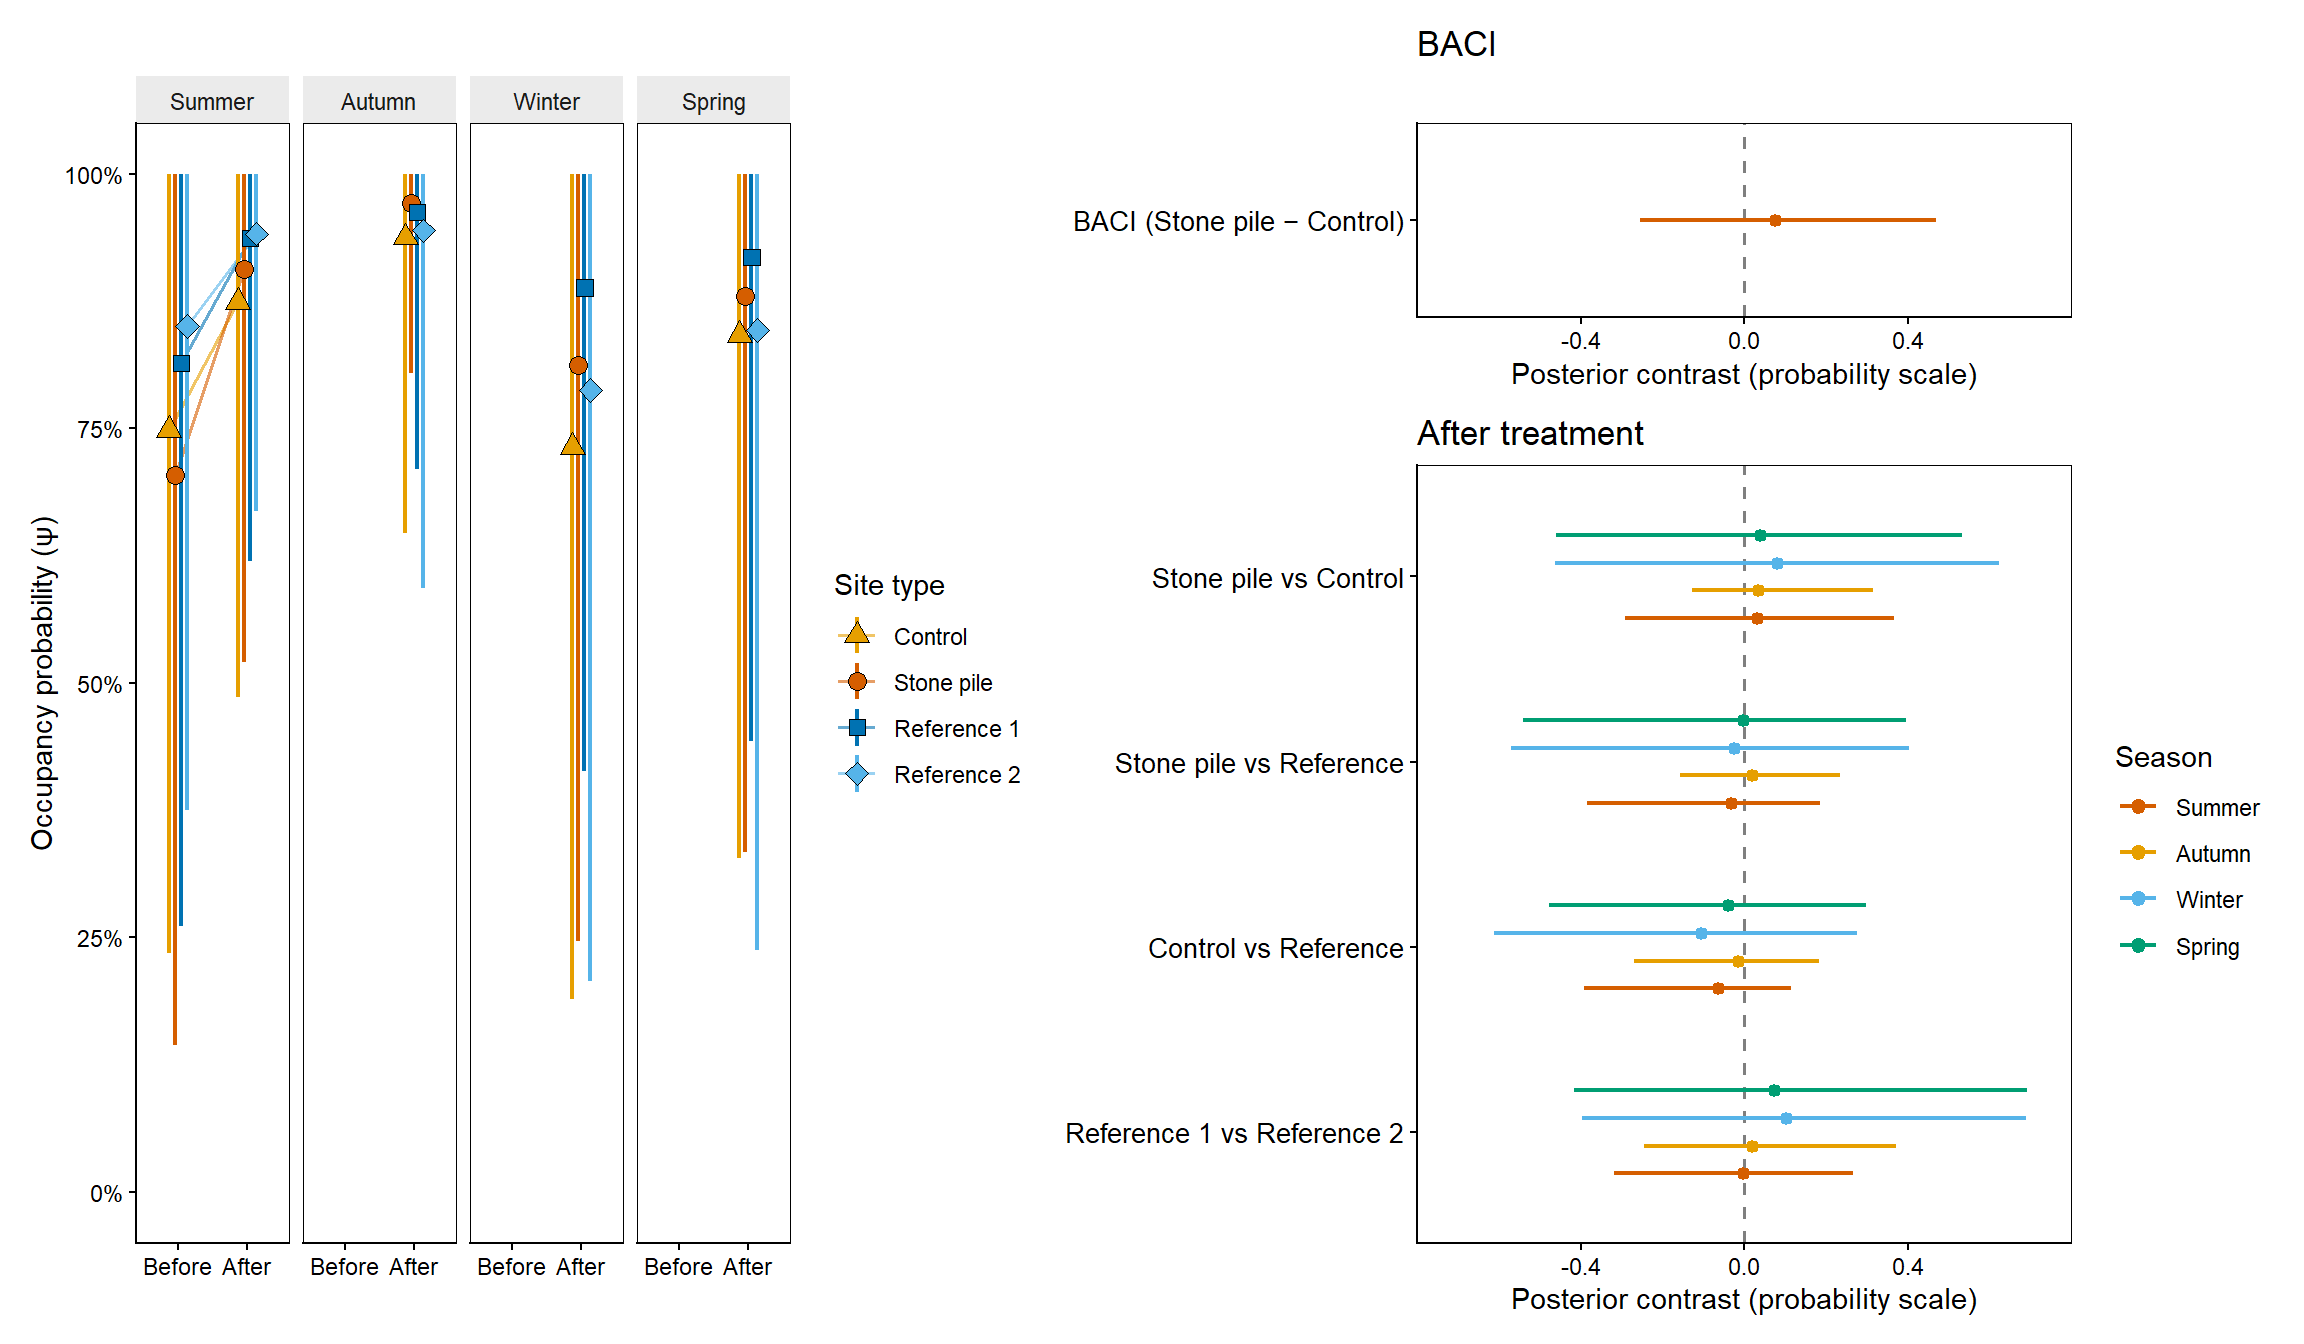

In [ ]:
results_full$psi_plot + results_full$contrast_plot


In [ ]:
results_summer <- run_contrasts(fit_summer, summer_data,
                                 model_label    = "summer",
                                 include_season = FALSE)



==== summer ====
# A tibble: 5 × 8
  model  contrast             period season     mean lower95 upper95 p_direction
  <chr>  <chr>                <chr>  <chr>     <dbl>   <dbl>   <dbl>       <dbl>
1 summer Stone_pile - Control After  <NA>    0.00536  -0.297   0.304       0.539
2 summer Reference1 - Refere… After  <NA>   -0.0341   -0.370   0.164       0.400
3 summer Control - Reference… After  <NA>   -0.0375   -0.329   0.117       0.406
4 summer Stone_pile - Refere… After  <NA>   -0.0322   -0.376   0.176       0.463
5 summer BACI: (Stone_pile A… Befor… <NA>    0.0418   -0.263   0.417       0.576

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

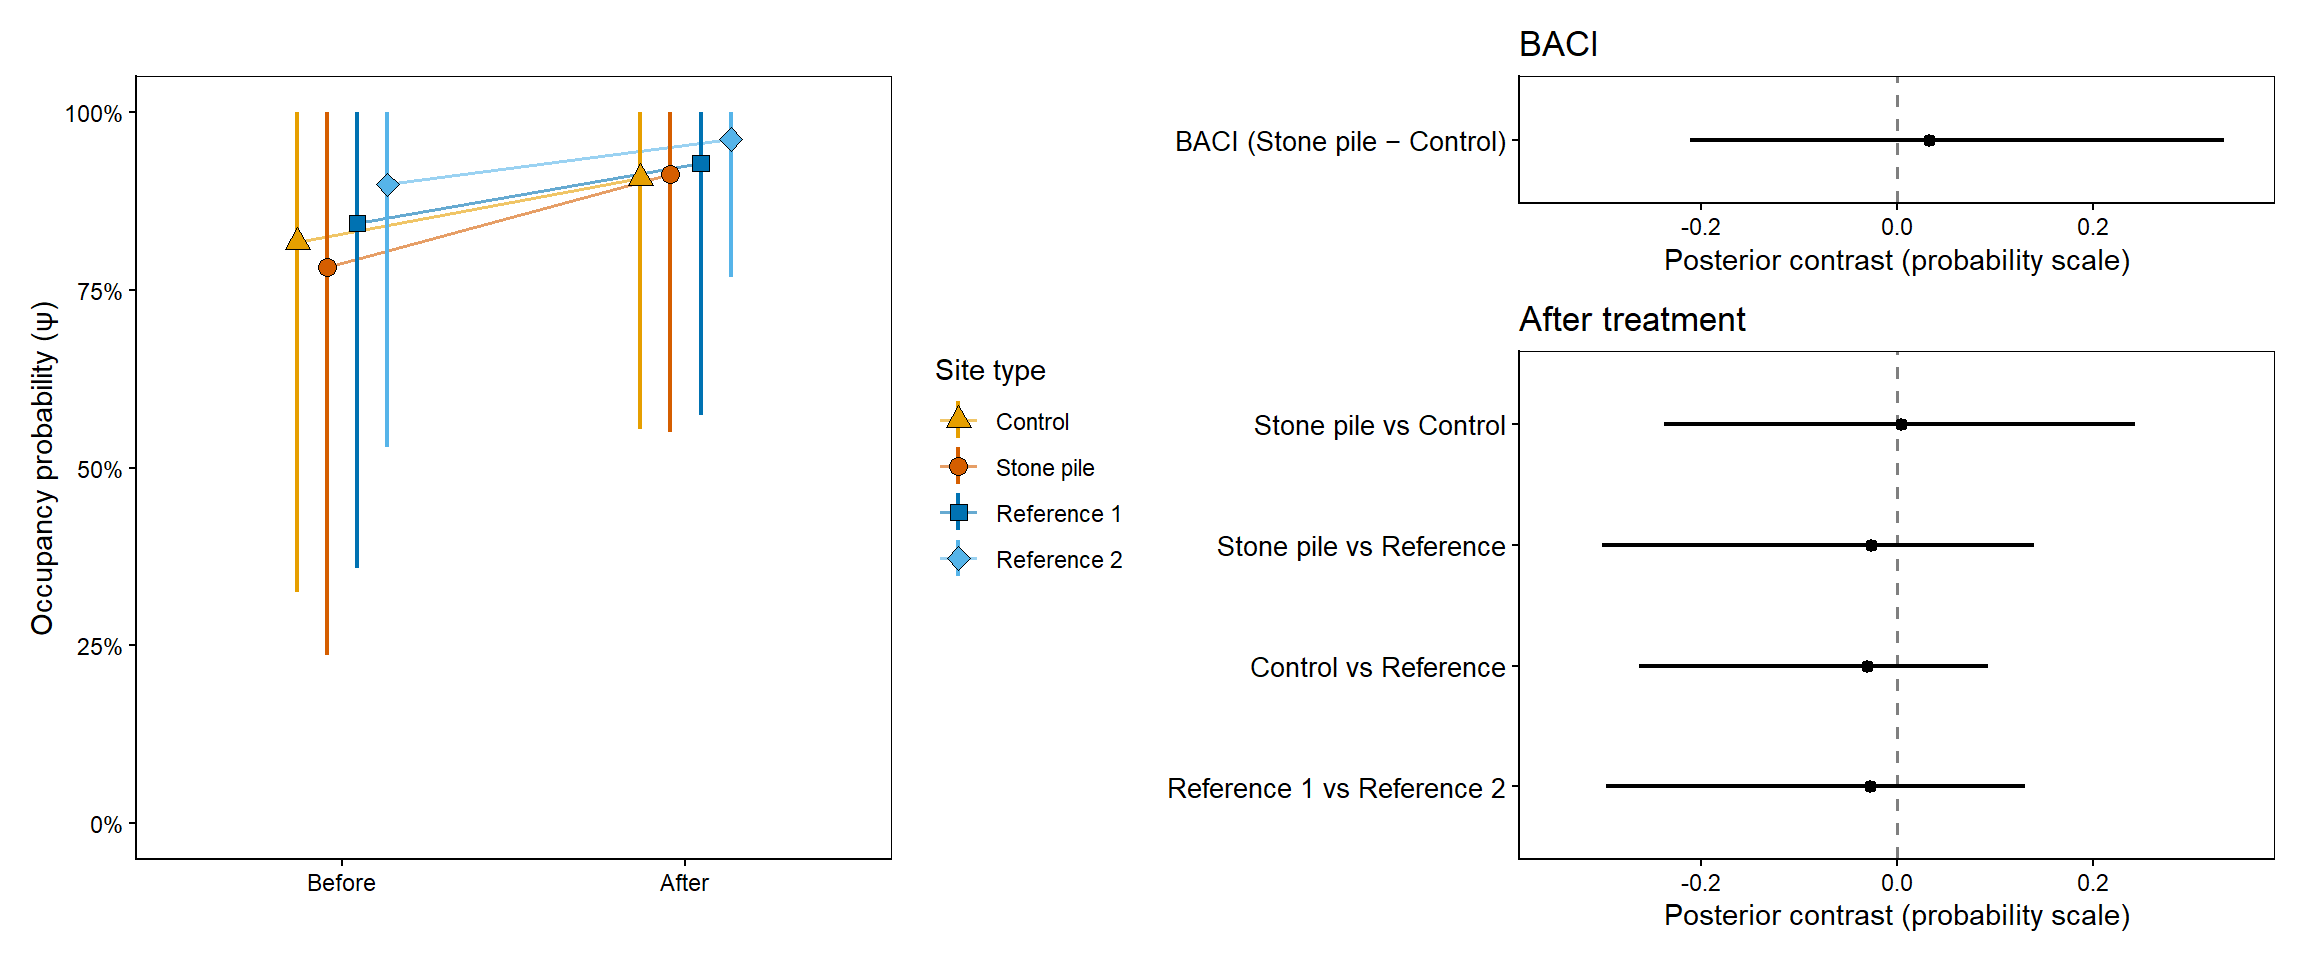

In [ ]:
results_summer$psi_plot + results_summer$contrast_plot


In [ ]:
results_warm <- run_contrasts(fit_warm, warm_data,
                               model_label    = "warm",
                               include_season = TRUE)



==== warm ====
# A tibble: 9 × 8
  model contrast              period season     mean lower95 upper95 p_direction
  <chr> <chr>                 <chr>  <fct>     <dbl>   <dbl>   <dbl>       <dbl>
1 warm  Stone_pile - Control  After  Summer  0.0453   -0.180   0.346       0.694
2 warm  Reference1 - Referen… After  Summer -0.00452  -0.307   0.253       0.518
3 warm  Control - Reference … After  Summer -0.0464   -0.346   0.121       0.365
4 warm  Stone_pile - Referen… After  Summer -0.00111  -0.254   0.194       0.572
5 warm  Stone_pile - Control  After  Autumn  0.0541   -0.155   0.369       0.694
6 warm  Reference1 - Referen… After  Autumn  0.00801  -0.268   0.291       0.518
7 warm  Control - Reference … After  Autumn -0.0478   -0.346   0.132       0.366
8 warm  Stone_pile - Referen… After  Autumn  0.00636  -0.226   0.211       0.571
9 warm  BACI: (Stone_pile Af… Befor… Summer  0.0614   -0.209   0.440       0.642

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

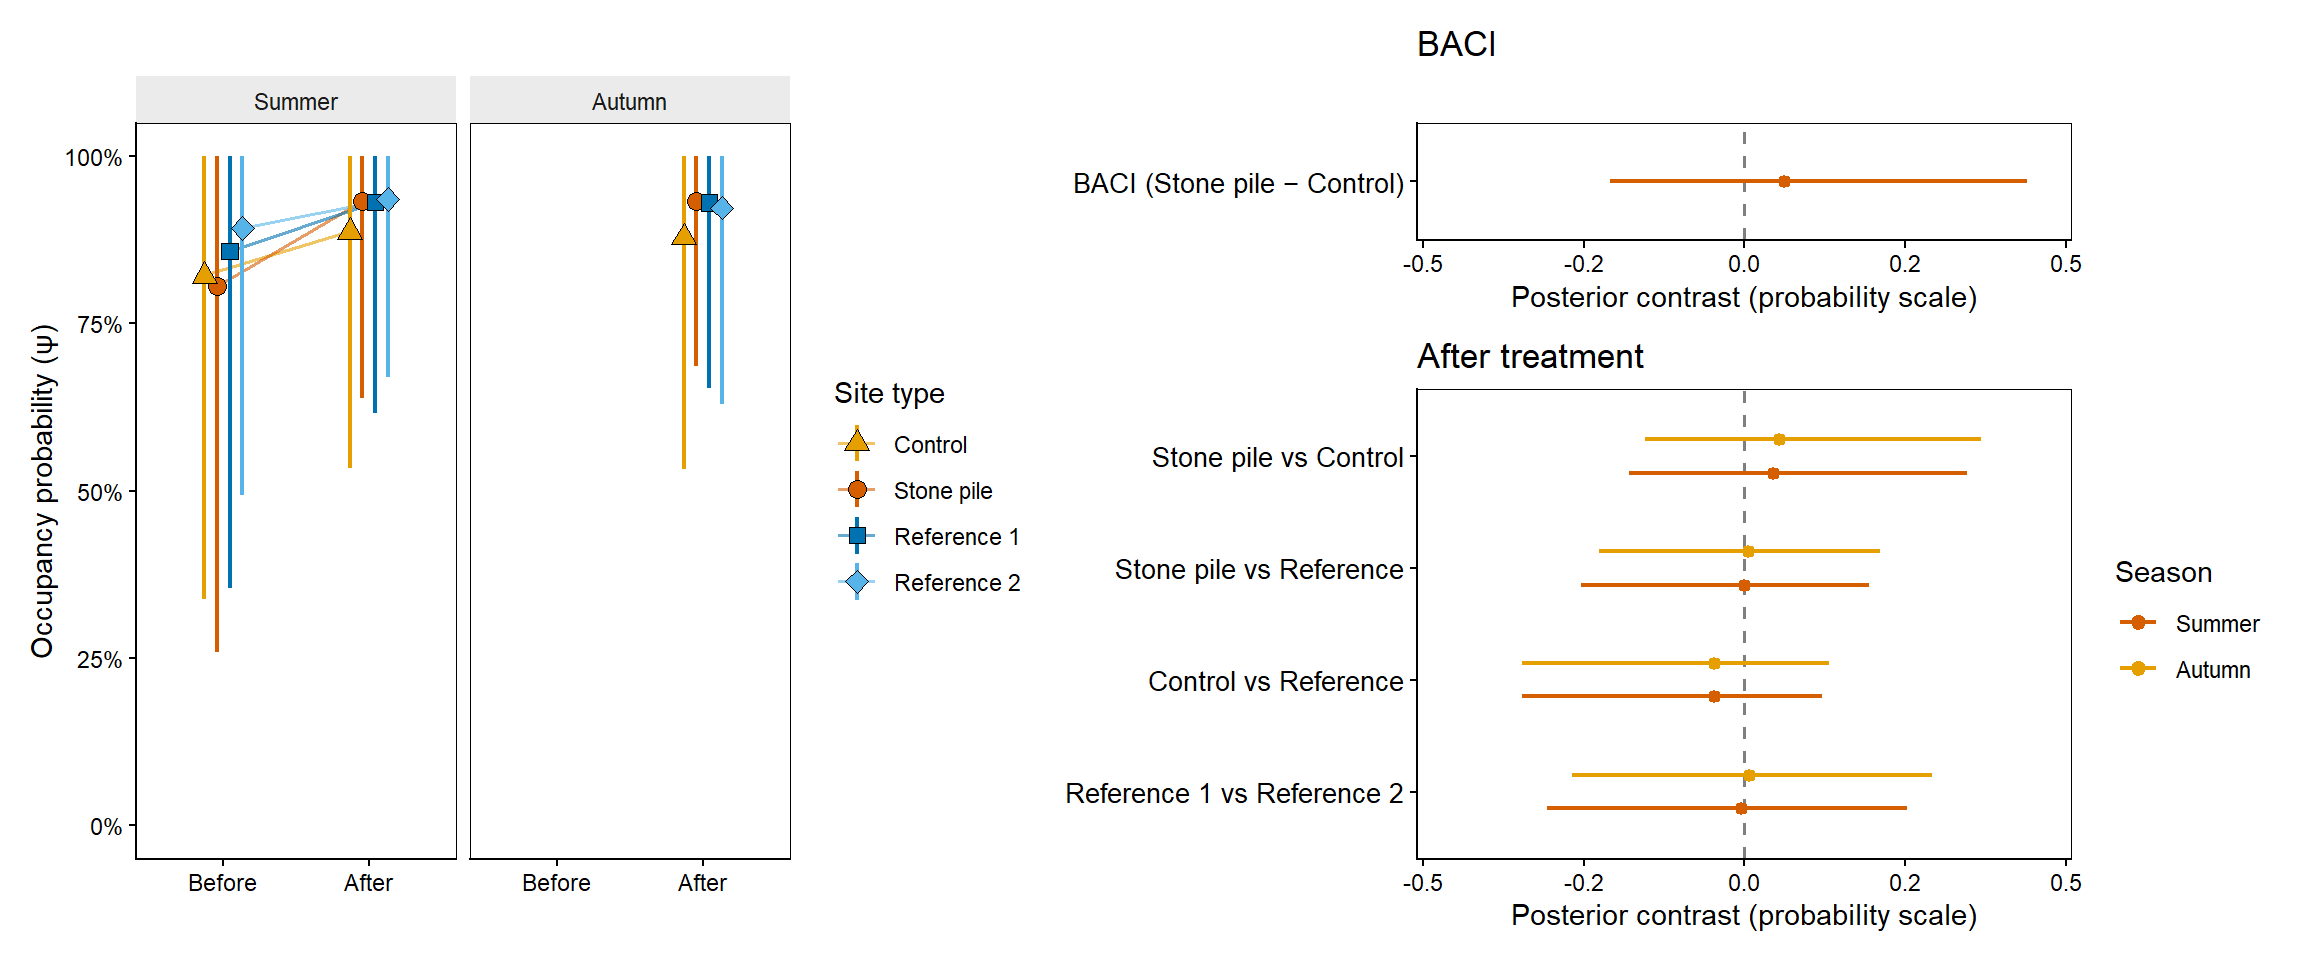

In [ ]:
results_warm$psi_plot + results_warm$contrast_plot


## table psi-warm

In [ ]:
psi_warm_tbl <- results_warm$cell_summary |>
  dplyr::mutate(
    season      = factor(season, levels = c("Summer", "Autumn")),
    period      = factor(period, levels = c("Before", "After")),
    location_type = factor(
                      dplyr::recode(as.character(location_type),
                        Stone_pile = "Stone pile",
                        Reference1 = "Reference 1",
                        Reference2 = "Reference 2"),
                      levels = c("Stone pile", "Control", "Reference 1", "Reference 2"))) |>
  dplyr::arrange(season, period, location_type) |>
  dplyr::transmute(
    Season      = as.character(season),
    Period      = as.character(period),
    `Site type` = location_type,
    `ψ (mean [95% CrI])` = sprintf("%.2f [%.2f–%.2f]", psi_mean, psi_lwr, psi_upr)
  )

readr::write_csv(psi_warm_tbl, file.path("outputs", "tbl-psi-warm.csv"))

knitr::kable(psi_warm_tbl, align = c("l", "l", "l", "c"))


  Season   Period   Site type      ψ (mean \[95% CrI\])
  -------- -------- ------------- ----------------------
  Summer   Before   Stone pile     0.81 \[0.26--1.00\]
  Summer   Before   Control        0.82 \[0.34--1.00\]
  Summer   Before   Reference 1    0.86 \[0.36--1.00\]
  Summer   Before   Reference 2    0.89 \[0.49--1.00\]
  Summer   After    Stone pile     0.93 \[0.64--1.00\]
  Summer   After    Control        0.89 \[0.53--1.00\]
  Summer   After    Reference 1    0.93 \[0.62--1.00\]
  Summer   After    Reference 2    0.94 \[0.67--1.00\]
  Autumn   After    Stone pile     0.93 \[0.69--1.00\]
  Autumn   After    Control        0.88 \[0.53--1.00\]
  Autumn   After    Reference 1    0.93 \[0.65--1.00\]
  Autumn   After    Reference 2    0.92 \[0.63--1.00\]


# Combined contrast summary

In [ ]:
all_contrasts <- dplyr::bind_rows(
  results_full$contrasts,
  results_summer$contrasts,
  results_warm$contrasts
)

readr::write_csv(all_contrasts,
  file.path(der_dir, "all_models_contrasts.csv"))

all_contrasts |>
  dplyr::select(model, contrast, period, season, mean, lower95, upper95, p_direction) |>
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3))) |>
  knitr::kable()


  ----------------------------------------------------------------------------------------------------------------
  model    contrast                          period            season       mean   lower95   upper95   p_direction
  -------- --------------------------------- ----------------- -------- -------- --------- --------- -------------
  full     Stone_pile - Control              After             Summer      0.032    -0.292     0.367         0.645

  full     Reference1 - Reference2           After             Summer     -0.004    -0.318     0.266         0.518

  full     Control - Reference (mean)        After             Summer     -0.064    -0.393     0.115         0.276

  full     Stone_pile - Reference (mean)     After             Summer     -0.032    -0.384     0.186         0.449

  full     Stone_pile - Control              After             Autumn      0.034    -0.129     0.315         0.716

  full     Reference1 - Reference2           After             Autumn      0.018    -0.246     0.371         0.535

  full     Control - Reference (mean)        After             Autumn     -0.016    -0.270     0.183         0.416

  full     Stone_pile - Reference (mean)     After             Autumn      0.018    -0.157     0.235         0.623

  full     Stone_pile - Control              After             Winter      0.080    -0.463     0.623         0.650

  full     Reference1 - Reference2           After             Winter      0.101    -0.398     0.690         0.645

  full     Control - Reference (mean)        After             Winter     -0.106    -0.613     0.277         0.331

  full     Stone_pile - Reference (mean)     After             Winter     -0.026    -0.570     0.403         0.505

  full     Stone_pile - Control              After             Spring      0.038    -0.460     0.534         0.637

  full     Reference1 - Reference2           After             Spring      0.072    -0.417     0.693         0.617

  full     Control - Reference (mean)        After             Spring     -0.040    -0.479     0.298         0.419

  full     Stone_pile - Reference (mean)     After             Spring     -0.003    -0.542     0.396         0.566

  full     BACI: (Stone_pile After-Before) - Before-vs-After   Summer      0.076    -0.256     0.469         0.662
           (Control After-Before)                                                                    

  summer   Stone_pile - Control              After             NA          0.005    -0.297     0.304         0.539

  summer   Reference1 - Reference2           After             NA         -0.034    -0.370     0.164         0.400

  summer   Control - Reference (mean)        After             NA         -0.038    -0.329     0.117         0.406

  summer   Stone_pile - Reference (mean)     After             NA         -0.032    -0.376     0.176         0.463

  summer   BACI: (Stone_pile After-Before) - Before-vs-After   NA          0.042    -0.263     0.417         0.577
           (Control After-Before)                                                                    

  warm     Stone_pile - Control              After             Summer      0.045    -0.180     0.346         0.694

  warm     Reference1 - Reference2           After             Summer     -0.005    -0.307     0.253         0.518

  warm     Control - Reference (mean)        After             Summer     -0.046    -0.346     0.121         0.365

  warm     Stone_pile - Reference (mean)     After             Summer     -0.001    -0.254     0.194         0.572

  warm     Stone_pile - Control              After             Autumn      0.054    -0.155     0.369         0.694

  warm     Reference1 - Reference2           After             Autumn      0.008    -0.268     0.291         0.518

  warm     Control - Reference (mean)        After             Autumn     -0.048    -0.346     0.132         0.366

  warm     Stone_pile - Reference (mean)     After             Autumn      0.006    -0.226     0.211         0.571

  warm     BACI: (Stone_pile After-Before) - Before-vs-After   Summer      0.061    -0.209     0.440         0.641
           (Control After-Before)                                                                    
  ----------------------------------------------------------------------------------------------------------------


# Additional and sensitivity models — wave exposure

Two sensitivity models test whether wave exposure confounds or modifies the primary results from the warm-season model:

- **Model S1 (fetch-ψ)**: adds max effective fetch (site-level, static) as a covariate on occupancy (ψ). Tests whether more exposed sites have systematically different baseline occupancy independent of treatment type.

- **Model S2 (wave-p)**: adds the round-specific wave energy proxy as an additional detection covariate alongside temperature. Tests whether high-energy rounds suppress detection probability.

LOO-IC comparison with the base warm model indicates whether either covariate improves predictive fit.

In [ ]:
site_fetch    <- readr::read_csv(file.path(der_dir, "site_fetch.csv"),
                                  show_col_types = FALSE)
wave_by_round <- readr::read_csv(file.path(der_dir, "wave_exposure_by_round.csv"),
                                  show_col_types = FALSE)

warm_data_fetch <- warm_data |>
  dplyr::left_join(
    site_fetch |> dplyr::select(site_id, max_eff_fetch_km),
    by = "site_id"
  ) |>
  dplyr::left_join(
    wave_by_round |> dplyr::select(site_id, round, wave_energy_proxy),
    by = c("site_id", "round")
  ) |>
  dplyr::mutate(
    fetch_z = as.numeric(scale(max_eff_fetch_km)),
    wave_z  = as.numeric(scale(wave_energy_proxy))
  )

cat("Fetch covariate range (km):", round(range(warm_data_fetch$max_eff_fetch_km), 2), "\n")


Fetch covariate range (km): 0.55 4.79 

Wave energy proxy range:    0 456273 

Missing wave_z:             0 rows

In [ ]:
fetch_psi_path <- file.path(der_dir, "fit_fetch_psi.rds")

if (!file.exists(fetch_psi_path)) {

  bf_fetch_psi <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + season + fetch_z + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_fetch_psi <- brm(
    bf_fetch_psi,
    data     = warm_data_fetch,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.99, max_treedepth = 13)
  )

  saveRDS(fit_fetch_psi, fetch_psi_path)
  cat("Fitted and saved fetch-ψ model.\n")

} else {
  fit_fetch_psi <- readRDS(fetch_psi_path)
  cat("Loaded cached fetch-ψ model.\n")
}


Loaded cached fetch-ψ model.

 Family: occ2 
  Links: mu = logit; pA = logit; pB = logit 
Formula: y_dummy | vint(yA_obs, yB_obs, yA, yB) ~ location_type * period + season + fetch_z + (1 | site_id) 
         pA ~ 1 + temp_z + (1 | site_id)
         pB ~ 1 + temp_z + (1 | site_id)
   Data: warm_data_fetch (Number of observations: 76) 
  Draws: 4 chains, each with iter = 4000; warmup = 1500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~site_id (Number of levels: 20) 
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)        1.39      0.79     0.08     2.96 1.00     1496     3314
sd(pA_Intercept)     1.92      0.55     0.91     3.10 1.00     4702     4392
sd(pB_Intercept)     0.97      0.63     0.05     2.32 1.00     1666     3072

Regression Coefficients:
                                    Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                               3.01      2.92    -0.59    10.59 1.00
pA_Intercept                      


Max Rhat:    1.002646 

Min ESS:     1163.182 

Divergences: 0 

In [ ]:
wave_p_path <- file.path(der_dir, "fit_wave_p.rds")

if (!file.exists(wave_p_path)) {

  bf_wave_p <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + season + (1 | site_id),
    pA ~ 1 + temp_z + wave_z + (1 | site_id),
    pB ~ 1 + temp_z + wave_z + (1 | site_id),
    family = occ2
  )

  fit_wave_p <- brm(
    bf_wave_p,
    data     = warm_data_fetch,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.99, max_treedepth = 13)
  )

  saveRDS(fit_wave_p, wave_p_path)
  cat("Fitted and saved wave-detection model.\n")

} else {
  fit_wave_p <- readRDS(wave_p_path)
  cat("Loaded cached wave-detection model.\n")
}


Loaded cached wave-detection model.

adapt_delta above 0.99 may help. See
http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup

 Family: occ2 
  Links: mu = logit; pA = logit; pB = logit 
Formula: y_dummy | vint(yA_obs, yB_obs, yA, yB) ~ location_type * period + season + (1 | site_id) 
         pA ~ 1 + temp_z + wave_z + (1 | site_id)
         pB ~ 1 + temp_z + wave_z + (1 | site_id)
   Data: warm_data_fetch (Number of observations: 76) 
  Draws: 4 chains, each with iter = 4000; warmup = 1500; thin = 1;
         total post-warmup draws = 10000

Multilevel Hyperparameters:
~site_id (Number of levels: 20) 
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)        1.41      0.80     0.08     3.00 1.00     1435     3146
sd(pA_Intercept)     1.92      0.56     0.91     3.10 1.00     6093     5668
sd(pB_Intercept)     1.07      0.68     0.05     2.49 1.00     1727     4374

Regression Coefficients:
                                    Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                               2.50      2.75    -0.73     9.27 1.00
pA_Intercept              


Max Rhat:    1.003317 

Min ESS:     1285.923 

Divergences: 5 

In [ ]:
loo_warm      <- loo(fit_warm,      reloo = TRUE)


No problematic observations found. Returning the original 'loo' object.

1 problematic observation(s) found.
The model will be refit 1 times.

Running MCMC with 4 chains, at most 20 in parallel...

Chain 3 finished in 12.0 seconds.
Chain 4 finished in 12.0 seconds.
Chain 1 finished in 12.4 seconds.
Chain 2 finished in 18.7 seconds.

All 4 chains finished successfully.
Mean chain execution time: 13.8 seconds.
Total execution time: 20.8 seconds.


Fitting model 1 out of 1 (leaving out observation 43)

Start sampling

...

Running MCMC with 4 chains, at most 20 in parallel...

Chain 3 finished in 12.3 seconds.
Chain 1 finished in 12.6 seconds.
Chain 2 finished in 13.3 seconds.
Chain 4 finished in 16.4 seconds.

All 4 chains finished successfully.
Mean chain execution time: 13.6 seconds.
Total execution time: 16.5 seconds.


Fitting model 1 out of 1 (leaving out observation 62)
Start sampling

See https://mc-stan.org/misc/warnings for details.

         model elpd_diff se_diff p_worse diag_diff diag_elpd
      fit_warm      0.00    0.00      NA                    
 fit_fetch_psi     -0.25    0.84    0.61   N < 100          
    fit_wave_p     -0.25    1.19    0.58   N < 100          


Diagnostic flags present.
See ?`loo-glossary` (sections `diag_diff` and `diag_elpd`)
or https://mc-stan.org/loo/reference/loo-glossary.html.

In [ ]:

fetch_coef <- posterior::as_draws_df(fit_fetch_psi) |>
  dplyr::select(b_fetch_z) |>
  tidyr::pivot_longer(everything(), names_to = "param", values_to = "value") |>
  dplyr::mutate(param = "fetch_z → ψ", model = "S1: fetch on ψ")


# Power analysis — sites and rounds needed for statistical detection

The current study shows a consistent positive direction for the stone pile effect but wide credible intervals due to limited site replication. This simulation-based power analysis asks: **how many site pairs, or how many additional monitoring rounds, would be needed to reliably detect the observed effect size?**

**Method:** Parameters (occupancy probabilities, detection rates, site-level variance) are drawn from the posterior means of the warm-season model. For each combination of site pairs and After rounds, 300 datasets are simulated and a logistic GLMM is fitted as a fast surrogate. Power = proportion of simulations where the 95 % CI of the BACI term (Stone pile × Period interaction) excludes zero.

In [ ]:
# Extract posterior means from the warm model
fe         <- brms::fixef(fit_warm)[, "Estimate"]
draws_warm <- posterior::as_draws_df(fit_warm)

logit_psi_ctrl_before <- fe["Intercept"]
b_period_after        <- fe["periodAfter"]
b_sp                  <- fe["location_typeStone_pile"]
b_sp_after            <- fe["location_typeStone_pile:periodAfter"]
logit_pA              <- fe["pA_Intercept"]
logit_pB              <- fe["pB_Intercept"]

# Site-level random effect SD (occupancy submodel)
sigma_site <- posterior::summarise_draws(fit_warm) |>
  dplyr::filter(variable == "sd_site_id__Intercept") |>
  dplyr::pull(mean)

# Report the key parameters being used
cat("Parameters extracted from warm model posterior means:\n")


Parameters extracted from warm model posterior means:

  ψ Control  Before: 0.946 

  ψ Control  After:  0.965 

  ψ Stone pile Before: 0.947 

  ψ Stone pile After:  0.983 

  pA (box trap):  0.425 

  pB (fyke net):  0.936 

  Site SD (logit):  1.35 

  BACI log-odds:   0.724 ≈ 0.018 probability units

In [ ]:
power_cache <- file.path(der_dir, "power_analysis.rds")

if (!file.exists(power_cache)) {

  # Simulate one dataset and test if the BACI term's 95% CI excludes zero
  one_sim <- function(n_pairs, n_after_rounds,
                      logit_psi_ctrl_before, b_period_after, b_sp, b_sp_after,
                      logit_pA, logit_pB, sigma_site) {

    pA <- plogis(logit_pA)
    pB <- plogis(logit_pB)
    n_before_rounds <- 1L   # matches study design: 1 Before round

    site_re <- rnorm(n_pairs * 2, 0, sigma_site)
    rows    <- vector("list", n_pairs * 2 * (n_before_rounds + n_after_rounds))
    idx     <- 0L

    for (pair in seq_len(n_pairs)) {
      for (st in c("Control", "Stone_pile")) {
        site_idx <- (pair - 1L) * 2L + if (st == "Control") 1L else 2L
        re_i     <- site_re[site_idx]

        for (period in c("Before", "After")) {
          n_rounds <- if (period == "Before") n_before_rounds else n_after_rounds
          for (r in seq_len(n_rounds)) {
            logit_psi <- logit_psi_ctrl_before +
              (if (period == "After")      b_period_after else 0) +
              (if (st == "Stone_pile")     b_sp           else 0) +
              (if (st == "Stone_pile" && period == "After") b_sp_after else 0) +
              re_i
            psi <- plogis(logit_psi)
            z   <- rbinom(1L, 1L, psi)
            yA  <- rbinom(1L, 1L, z * pA)
            yB  <- rbinom(1L, 1L, z * pB)
            idx <- idx + 1L
            rows[[idx]] <- data.frame(
              pair_id   = pair,
              site_id   = site_idx,
              site_type = st,
              period    = period,
              detected  = as.integer(yA | yB)
            )
          }
        }
      }
    }

    sim_data <- dplyr::bind_rows(rows) |>
      dplyr::mutate(
        period    = factor(period,    levels = c("Before", "After")),
        site_type = factor(site_type, levels = c("Control", "Stone_pile")),
        site_id   = factor(site_id),
        pair_id   = factor(pair_id)
      )

    # Fast logistic GLMM surrogate — skip if data is perfectly separated
    m <- tryCatch(
      lme4::glmer(detected ~ period * site_type + (1 | pair_id / site_id),
                  data = sim_data, family = binomial,
                  control = lme4::glmerControl(optimizer = "bobyqa")),
      error   = function(e) NULL,
      warning = function(w) NULL
    )
    if (is.null(m)) return(NA)

    coef_name <- grep("periodAfter:site_typeStone_pile",
                      names(lme4::fixef(m)), value = TRUE)
    if (length(coef_name) == 0) return(NA)
    est <- lme4::fixef(m)[coef_name]
    se  <- sqrt(diag(vcov(m)))[coef_name]
    # Wald 95% CI lower bound > 0 → BACI effect detected
    (est - 1.96 * se) > 0
  }

  run_power <- function(n_pairs, n_after_rounds, n_sims = 300) {
    results <- vapply(seq_len(n_sims), function(i)
      one_sim(n_pairs, n_after_rounds,
              logit_psi_ctrl_before, b_period_after, b_sp, b_sp_after,
              logit_pA, logit_pB, sigma_site),
      logical(1))
    mean(results, na.rm = TRUE)
  }

  set.seed(2026)
  power_grid <- tidyr::crossing(
    n_pairs        = c(3, 5, 7, 10, 15, 20, 30),
    n_after_rounds = c(2, 4, 6, 8, 10, 12)
  ) |>
    dplyr::mutate(
      power = purrr::map2_dbl(n_pairs, n_after_rounds, run_power,
                               .progress = TRUE)
    )

  saveRDS(power_grid, power_cache)
  cat("Power analysis complete and cached.\n")

} else {
  power_grid <- readRDS(power_cache)
  cat("Loaded cached power analysis.\n")
}


Loaded cached power analysis.

# A tibble: 7 × 7
  n_pairs rounds_2 rounds_4 rounds_6 rounds_8 rounds_10 rounds_12
    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>     <dbl>     <dbl>
1       3  0        0        0        0          0        0      
2       5  0        0        0.00375  0          0        0.00372
3       7  0        0        0        0          0        0      
4      10  0        0.00358  0        0.00712    0.0107   0.0140 
5      15  0.00348  0.0138   0.00694  0.00350    0.0275   0.0138 
6      20  0.0172   0.0372   0.0173   0.0341     0.0411   0.0238 
7      30  0.0271   0.0533   0.0777   0.0436     0.0471   0.0442 

In [ ]:
p_lines <- power_grid |>
  dplyr::mutate(n_after_rounds = factor(n_after_rounds,
                  labels = paste0(c(2,4,6,8,10,12), " After rounds"))) |>
  ggplot(aes(x = n_pairs, y = power, colour = n_after_rounds,
             group = n_after_rounds)) +
  geom_hline(yintercept = 0.8, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  annotate("text", x = max(power_grid$n_pairs) * 0.98, y = 0.82,
           label = "80 % power", hjust = 1, colour = "grey40", size = 3.5) +
  scale_colour_manual(
    values = c("#313695","#4575b4","#74add1","#f46d43","#d73027","#a50026"),
    name   = NULL
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
  scale_x_continuous(breaks = c(3, 5, 7, 10, 15, 20, 30)) +
  labs(title = "Occupancy (BACI)",
       x = "Number of site pairs (Stone pile + Control)",
       y = "Statistical power") +
  base_theme +
  theme(panel.grid.minor = element_blank(), legend.position = "right")


In [ ]:
# What does it take to hit 80% power at the current effect size?
power_grid |>
  dplyr::filter(power >= 0.8) |>
  dplyr::group_by(n_after_rounds) |>
  dplyr::slice_min(n_pairs, n = 1) |>
  dplyr::ungroup() |>
  dplyr::transmute(
    `After rounds` = n_after_rounds,
    `Site pairs needed` = n_pairs,
    `Power achieved` = scales::percent(power, accuracy = 1)
  ) |>
  knitr::kable()


    After rounds   Site pairs needed Power achieved
  -------------- ------------------- ----------------


# CPUE-based Power Analysis (M2aak — Kōura abundance BACI)

The occupancy analysis sits near a ceiling (ψ ≈ 0.81–0.95) so the detectable BACI signal is compressed. CPUE captures the abundance dimension that occupancy misses. M2aak (Kōura CPUE, Stone_pile vs Control, full BACI) shows a positive but non-significant BACI of 0.311 log-units (×1.36 on the ratio scale, p = 0.800). This power analysis asks: how many site pairs and monitoring rounds would be needed to detect an effect of that size at 80% power?

**Model structure simulated:** `log(CPUE) ~ period * site_type + monitoring_int + (1|pair_id) + (1|site_id)`

Fixed effects come directly from M2aak. Random effect SDs and the log-scale residual SD are set to ecologically plausible defaults — update them from `VarCorr(M2aak)` and `sigma(M2aak)` if you want exact values.

In [ ]:
library(lme4)


Loading required package: Matrix


Attaching package: 'Matrix'

The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Attaching package: 'lme4'

The following object is masked from 'package:brms':

    ngrps

...

  BACI estimate:   0.311 (SE = 1.232, p = 0.800)

  95% CI on BACI: [-2.10, 2.73]

  Ratio scale:     exp(0.311) = 1.36×

  PeriodAfter:     2.374 (strong time effect; both sites gain)

  monitoring_int:  -0.253 (declining trend over rounds)

In [ ]:

one_sim_cpue <- function(n_pairs, n_after_rounds) {

  dat <- tidyr::crossing(
    pair_idx  = seq_len(n_pairs),
    site_type = c("Control", "Stone_pile"),
    round_no  = 0L:as.integer(n_after_rounds)
  ) |>
    dplyr::mutate(
      pair_id        = factor(paste0("p", pair_idx)),
      site_id        = factor(paste0("p", pair_idx, "_", site_type)),
      period         = factor(ifelse(round_no == 0L, "Before", "After"),
                              levels = c("Before", "After")),
      monitoring_int = as.numeric(round_no),
      is_sp          = as.integer(site_type == "Stone_pile"),
      is_after       = as.integer(period == "After")
    )

  # Sample random effects for this iteration
  re_pair <- stats::setNames(
    rnorm(n_pairs, 0, sigma_pair_cpue),
    paste0("p", seq_len(n_pairs))
  )
  re_site <- stats::setNames(
    rnorm(n_pairs * 2L, 0, sigma_site_cpue),
    paste0("p", rep(seq_len(n_pairs), each = 2L), "_",
           c("Control", "Stone_pile"))
  )

  dat <- dat |>
    dplyr::mutate(
      eta  = cpue_b0 +
             cpue_b_after * is_after +
             cpue_b_sp    * is_sp +
             cpue_b_time  * monitoring_int +
             cpue_b_baci  * (is_after * is_sp) +
             re_pair[as.character(pair_id)] +
             re_site[as.character(site_id)],
      cpue = exp(stats::rnorm(dplyr::n(), eta, sigma_resid_cpue))
    )

  fit <- tryCatch(
    suppressWarnings(
      lme4::lmer(log(cpue) ~ period * site_type + monitoring_int +
                   (1 | pair_id) + (1 | site_id),
                 data = dat, REML = FALSE)
    ),
    error = function(e) NULL
  )

  if (is.null(fit)) return(NA_real_)

  cf  <- lme4::fixef(fit)
  vcv <- as.matrix(vcov(fit))
  nm  <- "periodAfter:site_typeStone_pile"
  if (!nm %in% names(cf)) return(NA_real_)

  est <- cf[nm]
  se  <- sqrt(vcv[nm, nm])
  if (is.na(se) || se < 1e-9) return(NA_real_)

  # Two-sided 95% CI must exclude zero in positive direction
  as.numeric((est - 1.96 * se) > 0)
}

run_power_cpue <- function(n_pairs, n_after_rounds, n_sims = 300L) {
  results <- vapply(
    seq_len(n_sims),
    function(s) {
      set.seed(s * 100L + n_pairs * 10L + n_after_rounds)
      one_sim_cpue(n_pairs, n_after_rounds)
    },
    numeric(1L)
  )
  mean(results, na.rm = TRUE)
}

cpue_power_cache <- file.path(der_dir, "cpue_power_analysis.rds")

if (!file.exists(cpue_power_cache)) {
  cat("Running CPUE power analysis (200 sims × 42 scenarios)...\n")

  cpue_power_grid <- tidyr::crossing(
    n_pairs        = c(3L, 5L, 7L, 10L, 15L, 20L, 30L),
    n_after_rounds = c(2L, 4L, 6L, 8L, 10L, 12L)
  ) |>
    dplyr::mutate(
      power = purrr::map2_dbl(n_pairs, n_after_rounds, run_power_cpue,
                              .progress = TRUE)
    )

  saveRDS(cpue_power_grid, cpue_power_cache)
  cat("CPUE power analysis complete and cached.\n")

} else {
  cpue_power_grid <- readRDS(cpue_power_cache)
  cat("Loaded cached CPUE power analysis.\n")
}


Loaded cached CPUE power analysis.

# A tibble: 7 × 7
  n_pairs rounds_2 rounds_4 rounds_6 rounds_8 rounds_10 rounds_12
    <int>    <dbl>    <dbl>    <dbl>    <dbl>     <dbl>     <dbl>
1       3    0.12     0.115    0.065    0.075     0.075     0.05 
2       5    0.105    0.08     0.11     0.065     0.075     0.065
3       7    0.105    0.105    0.085    0.085     0.06      0.095
4      10    0.12     0.095    0.13     0.135     0.14      0.1  
5      15    0.16     0.12     0.135    0.135     0.135     0.125
6      20    0.165    0.2      0.14     0.155     0.14      0.15 
7      30    0.205    0.215    0.23     0.26      0.21      0.2  

In [ ]:
p_lines_cpue <- cpue_power_grid |>
  dplyr::mutate(n_after_rounds = factor(n_after_rounds,
                  labels = paste0(c(2, 4, 6, 8, 10, 12), " After rounds"))) |>
  ggplot(aes(x = n_pairs, y = power, colour = n_after_rounds,
             group = n_after_rounds)) +
  geom_hline(yintercept = 0.8, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  annotate("text", x = max(cpue_power_grid$n_pairs) * 0.98, y = 0.82,
           label = "80 % power", hjust = 1, colour = "grey40", size = 3.5) +
  scale_colour_manual(
    values = c("#313695", "#4575b4", "#74add1", "#f46d43", "#d73027", "#a50026"),
    name   = NULL
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
  scale_x_continuous(breaks = c(3, 5, 7, 10, 15, 20, 30)) +
  labs(title = "Kōura CPUE (BACI)",
       x = "Number of site pairs (Stone pile + Control)",
       y = "Statistical power") +
  base_theme +
  theme(panel.grid.minor = element_blank(), legend.position = "right")


Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

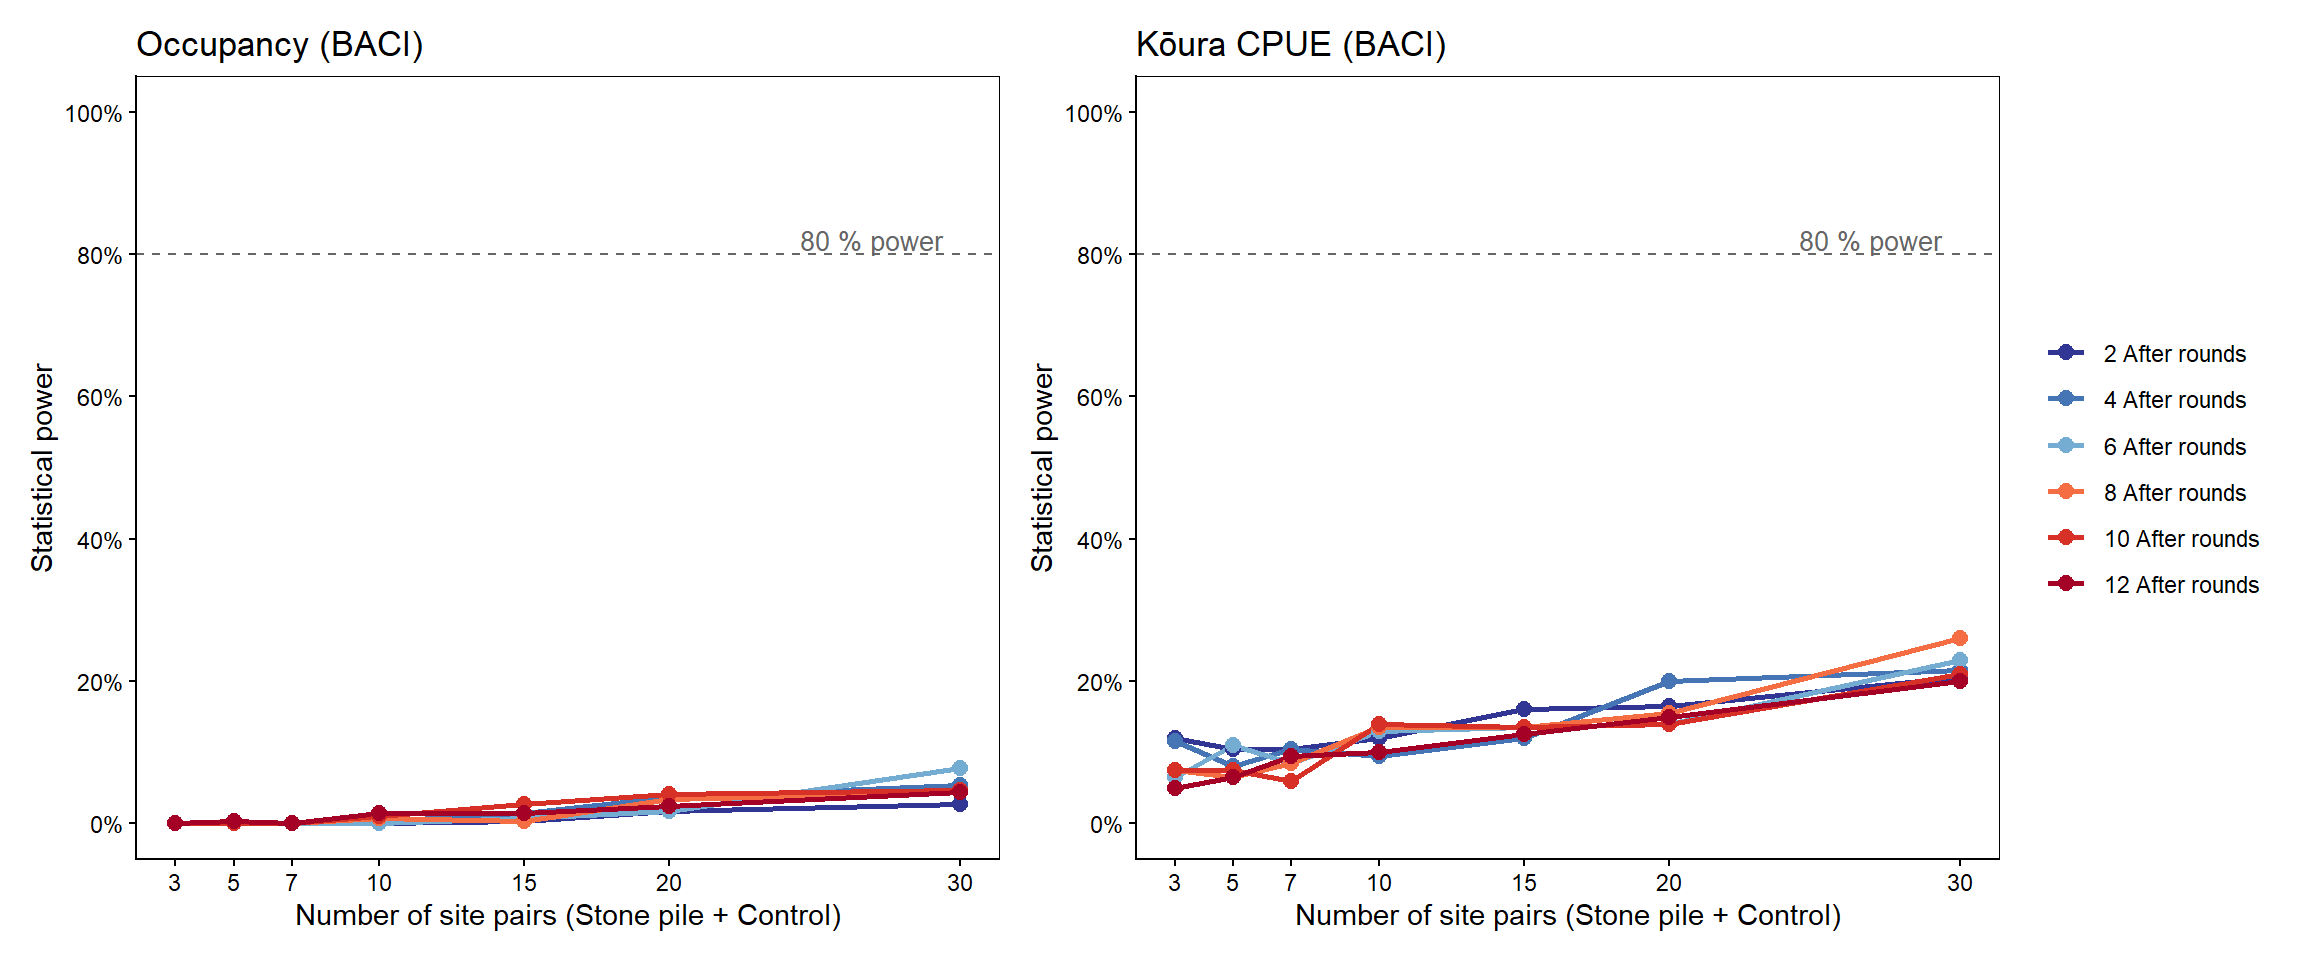

In [ ]:
p_power_combined <- p_lines + p_lines_cpue +
  patchwork::plot_layout(guides = "collect") &
  theme(legend.position = "right")

ggsave(file.path("outputs", "fig-power-curves-combined.png"),
       p_power_combined, width = 12, height = 5, dpi = 300)
p_power_combined


In [ ]:
at_80 <- cpue_power_grid |>
  dplyr::filter(power >= 0.8) |>
  dplyr::group_by(n_after_rounds) |>
  dplyr::slice_min(n_pairs, n = 1) |>
  dplyr::ungroup() |>
  dplyr::transmute(
    `After rounds`      = n_after_rounds,
    `Site pairs needed` = n_pairs,
    `Power achieved`    = scales::percent(power, accuracy = 1)
  )

cap <- paste0(
  "CPUE BACI power (M2aak: exp(BACI) = ", round(exp(cpue_b_baci), 2), "×; ",
  "σ_pair = ", sigma_pair_cpue, ", σ_site = ", sigma_site_cpue,
  ", σ_resid = ", sigma_resid_cpue, "). ",
  "Log-normal surrogate (lmer)."
)

if (nrow(at_80) == 0) {
  cat("No scenario in the grid reaches 80% power.\n")
  cat(sprintf("Maximum power achieved: %.0f%% (n_pairs = 30, rounds = 8).\n",
              100 * max(cpue_power_grid$power)))
  cat("The between-pair variance (σ_pair = 1.30) dominates, matching the\n")
  cat("occupancy result: more rounds do not compensate for too few pairs.\n")
  cpue_power_grid |>
    dplyr::filter(power == max(power)) |>
    knitr::kable()
} else {
  knitr::kable(at_80)
}


No scenario in the grid reaches 80% power.
Maximum power achieved: 26% (n_pairs = 30, rounds = 8).
The between-pair variance (σ_pair = 1.30) dominates, matching the
occupancy result: more rounds do not compensate for too few pairs.

    n_pairs   n_after_rounds   power
  --------- ---------------- -------
         30                8    0.26


# CPUE effect size trajectory — when will detection become feasible?

The power analyses above assume the current BACI effect size stays fixed. But M2bak (kōura CPUE, after-period trajectory) shows stone pile CPUE is declining more slowly than controls (+0.243 log-units per round divergence). If this trajectory continues, the cumulative CPUE BACI effect grows with each monitoring round, eventually crossing the detection threshold for 5 pairs.

Note: this projection applies to **CPUE detection only**. Occupancy detection is structurally limited by the near-ceiling ψ values and does not benefit meaningfully from a growing effect — the signal is compressed regardless of effect size.

At 4 quarterly rounds per year, 5–6 additional rounds corresponds to approximately **1.5 years** of continued monitoring — assuming the trajectory holds.

**Caveat:** kōura colonisation of stone pile habitat is expected to saturate as structures approach carrying capacity. The linear projection is therefore an optimistic lower bound — the true detection horizon is likely later.

Detection threshold (80% power, 5 pairs): 1.80 log-units (6.0×)

Current BACI: 0.311 log-units (1.36×)

Gap to threshold: 1.49 log-units

Rounds needed (linear): 6.1 additional quarterly rounds (~1.5 years)

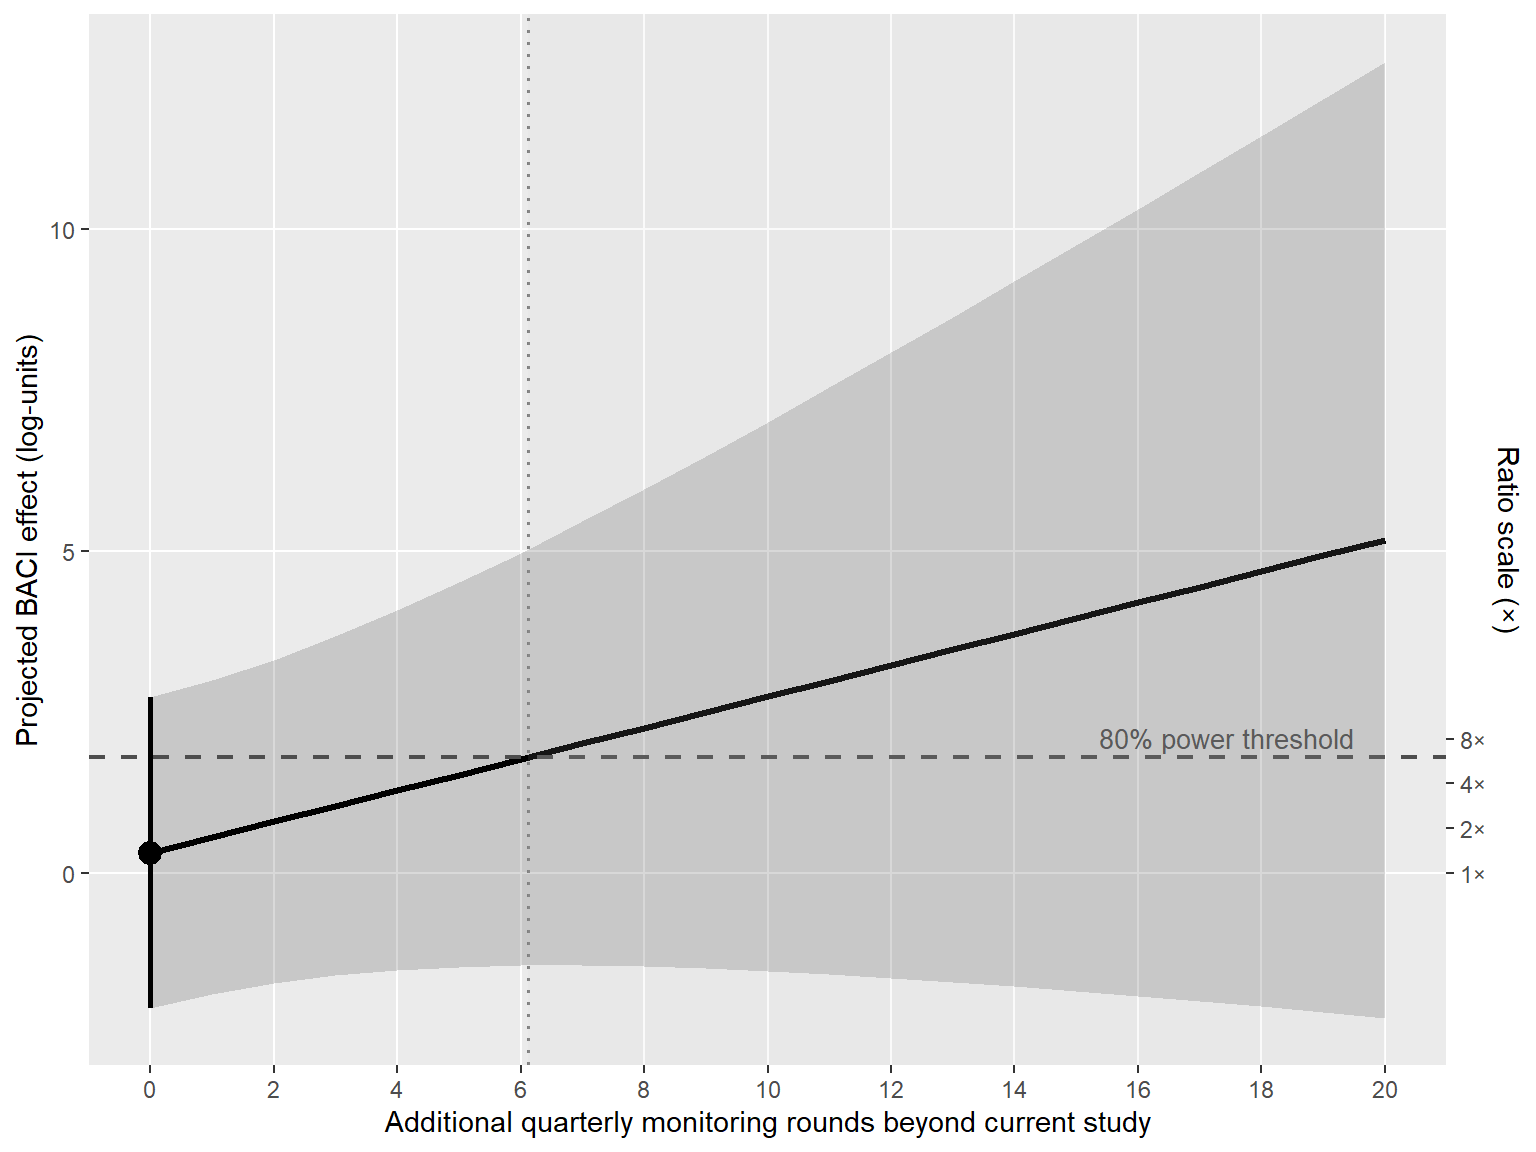

In [ ]:

# Parameters read from model summary CSV (written by analysis.qmd)
baci_now       <- cpue_b_baci   # M2aak BACI — already loaded in cpue-params
baci_se_now    <- cpue_baci_se  # M2aak BACI SE

traj_per_round <- get_fe("M2bak", "siteStone_pile:monitoring_int")
traj_se        <- get_fe("M2bak", "siteStone_pile:monitoring_int", "std.error")

# Detection threshold: SE at n=30 back-calculated from simulation results
ref_power_30 <- cpue_power_grid |>
  dplyr::filter(n_pairs == 30) |>
  dplyr::summarise(p = mean(power)) |>
  dplyr::pull(p)
se_at_30 <- baci_now / (qnorm(ref_power_30) + qnorm(0.975))
se_at_5  <- se_at_30 * sqrt(30 / 5)
threshold  <- (qnorm(0.975) + qnorm(0.80)) * se_at_5

cat(sprintf("Detection threshold (80%% power, 5 pairs): %.2f log-units (%.1f×)\n",
            threshold, exp(threshold)))


In [ ]:

# Analytically compute n_pairs needed to detect baci_now at 80% power.
# SE scales as se_at_n = se_at_30 * sqrt(30 / n), so:
#   baci_now = (z_alpha + z_beta) * se_at_n  →  n = 30 * (se_at_30 * z_sum / baci_now)^2
z_sum         <- qnorm(0.975) + qnorm(0.80)
n_pairs_needed <- ceiling(30 * (se_at_30 * z_sum / baci_now)^2)

max_cpue_power <- max(cpue_power_grid$power)
max_occ_power  <- max(power_grid$power)

power_scalars <- tibble::tibble(
  key   = c("baci_effect", "baci_se",
            "threshold_80", "threshold_ratio",
            "traj_per_round", "traj_se",
            "rounds_to_80", "years_to_80",
            "n_pairs_needed",
            "max_cpue_power", "max_occ_power"),
  value = c(round(baci_now, 3),       round(baci_se_now, 3),
            round(threshold, 2),      round(threshold / baci_now, 1),
            round(traj_per_round, 3), round(traj_se, 3),
            round(rounds_to_80, 1),   round(rounds_to_80 / 4, 1),
            n_pairs_needed,
            round(max_cpue_power, 3), round(max_occ_power, 3))
)

readr::write_csv(power_scalars, file.path("outputs", "tbl-power-scalars.csv"))
power_scalars


# A tibble: 11 × 2
   key               value
   <chr>             <dbl>
 1 baci_effect       0.311
 2 baci_se           1.23 
 3 threshold_80      1.8  
 4 threshold_ratio   5.8  
 5 traj_per_round    0.243
 6 traj_se           0.179
 7 rounds_to_80      6.1  
 8 years_to_80       1.5  
 9 n_pairs_needed  167    
10 max_cpue_power    0.26 
11 max_occ_power     0.078

# Session info

In [ ]:
sessionInfo()


R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices datasets  utils     methods   base     

other attached packages:
 [1] lme4_2.0-6       Matrix_1.7-5     future_1.75.0    patchwork_1.3.2 
 [5] bayesplot_1.15.0 posterior_1.7.0  tidybayes_3.0.7  lubridate_1.9.5 
 [9] forcats_1.0.1    stringr_1.6.0    dplyr_1.2.1      purrr_1.2.2     
[13] readr_2.2.0      tidyr_1.3.2      tibble_3.3.1     ggplot2_4.0.3   
[17] tidyverse_2.0.0  cmdstanr_0.9.0   brms_2.23.0      Rcpp_1.1.2      

loaded via a namespace (and not attached):
 [1] Rdpack_2.6.6         gridExtra_2.3.1     

```` markdown
---
title: "Kōura two-method occupancy analysis — Lake Rotoiti stone-pile BACI"
format: html
execute:
  message: false
  warning: false
---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
library(brms)
library(cmdstanr)
library(tidyverse)
library(tidybayes)
library(posterior)
library(bayesplot)
library(patchwork)


options(brms.backend = "cmdstanr")
options(mc.cores = parallel::detectCores())

base_theme <- theme_classic() +
  theme(
    text         = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
  )
theme_set(base_theme)

der_dir <- file.path("data", "derived")
dir.create(der_dir, showWarnings = FALSE, recursive = TRUE)

location_levels <- c("Stone_pile", "Control", "Reference1", "Reference2")
period_levels   <- c("Before", "After")
season_levels   <- c("Summer", "Autumn", "Winter", "Spring")
block_levels    <- c("Impact", "Reference")

round_lookup <- tibble(
  round  = 0:6,
  period = c("Before", rep("After", 6)),
  season = c("Summer", "Autumn", "Winter", "Spring", "Summer", "Autumn", "Winter"),
  year   = c(1, 1, 1, 1, 2, 2, 2)
) |>
  mutate(
    period = factor(period, levels = period_levels),
    season = factor(season, levels = season_levels)
  )

print(round_lookup)
```

# Custom two-method occupancy family

Two detection methods deployed at every site every round:

- **Method A** — Box traps (~32 % detection probability)
- **Method B** — Fyke nets (~63 % detection probability)

The custom brms/Stan family marginalises the latent occupancy state *z* over both
methods jointly, and tolerates partial missingness (one trap lost to storms) via
four `vint()` helper columns per occasion: `yA_obs`, `yB_obs` (trap retrieved?),
`yA`, `yB` (kōura detected?).

quarto-executable-code-5450563D

```r
#| label: occupancy-family
stan_funs_occ <- "
  real occ2_lpmf(int y, real psi, real pA, real pB,
                  int yA_obs, int yB_obs, int yA, int yB) {
    real ll_given_occ = 0;
    int any_detect = 0;

    if (yA_obs == 1) {
      ll_given_occ += yA * log(pA) + (1 - yA) * log1m(pA);
      if (yA == 1) any_detect = 1;
    }
    if (yB_obs == 1) {
      ll_given_occ += yB * log(pB) + (1 - yB) * log1m(pB);
      if (yB == 1) any_detect = 1;
    }

    if (any_detect == 1) {
      return log(psi) + ll_given_occ;
    } else {
      return log_sum_exp(log(psi) + ll_given_occ, log1m(psi));
    }
  }
"

stanvars_occ <- brms::stanvar(scode = stan_funs_occ, block = "functions")

# brms custom family — dpars must start with "mu" (brms >= 2.21)
# mu maps to psi (true occupancy); pA and pB are detection submodels
# vars must use brms internal vint names matching vint() order in formula
occ2 <- custom_family(
  name  = "occ2",
  dpars = c("mu", "pA", "pB"),
  links = c("logit", "logit", "logit"),
  lb    = c(0, 0, 0),
  ub    = c(1, 1, 1),
  type  = "int",
  vars  = c("vint1[n]", "vint2[n]", "vint3[n]", "vint4[n]")
)

log_lik_occ2 <- function(i, prep) {
  psi    <- brms::get_dpar(prep, "mu", i = i)
  pA     <- brms::get_dpar(prep, "pA", i = i)
  pB     <- brms::get_dpar(prep, "pB", i = i)
  yA_obs <- prep$data$vint1[i]; yB_obs <- prep$data$vint2[i]
  yA     <- prep$data$vint3[i]; yB     <- prep$data$vint4[i]
  ll_given_occ <- 0; any_detect <- 0
  if (yA_obs == 1) {
    ll_given_occ <- ll_given_occ + yA * log(pA) + (1 - yA) * log1p(-pA)
    if (yA == 1) any_detect <- 1
  }
  if (yB_obs == 1) {
    ll_given_occ <- ll_given_occ + yB * log(pB) + (1 - yB) * log1p(-pB)
    if (yB == 1) any_detect <- 1
  }
  if (any_detect == 1) log(psi) + ll_given_occ
  else log(psi * exp(ll_given_occ) + (1 - psi))
}

posterior_predict_occ2 <- function(i, prep, ...) {
  psi    <- brms::get_dpar(prep, "mu", i = i)
  pA     <- brms::get_dpar(prep, "pA", i = i)
  pB     <- brms::get_dpar(prep, "pB", i = i)
  yA_obs <- prep$data$vint1[i]; yB_obs <- prep$data$vint2[i]
  z      <- rbinom(length(psi), 1, psi)
  yA_sim <- ifelse(yA_obs == 1, rbinom(length(psi), 1, z * pA), NA_integer_)
  yB_sim <- ifelse(yB_obs == 1, rbinom(length(psi), 1, z * pB), NA_integer_)
  rowSums(cbind(yA_sim, yB_sim), na.rm = TRUE)
}

# posterior_epred returns psi (true occupancy), not detection-weighted catch
posterior_epred_occ2 <- function(prep) {
  brms::get_dpar(prep, "mu")
}

cat("Custom family 'occ2' defined.\n")
```

# Import and prepare data
quarto-executable-code-5450563D

```r
#| label: import-data
model_data_path <- file.path(der_dir, "model_data.rds")

if (!file.exists(model_data_path)) {

  combined <- readr::read_csv(file.path("data", "derived", "Combined_data.csv"),
                               show_col_types = FALSE)
  fish     <- readr::read_csv(file.path("data", "derived", "Fish_data.csv"),
                               show_col_types = FALSE)

  backbone <- combined |>
    dplyr::transmute(
      site_id            = as.integer(site_id),
      round              = as.integer(monitoring),
      monitoring_id      = monitoring_id,
      location_type      = dplyr::case_when(
        Site_type_detail == "Stone_pile"  ~ "Stone_pile",
        Site_type_detail == "Control"     ~ "Control",
        Site_type_detail == "Reference_1" ~ "Reference1",
        Site_type_detail == "Reference_2" ~ "Reference2",
        TRUE                              ~ NA_character_),
      block              = dplyr::case_when(
        Site_type_detail %in% c("Stone_pile", "Control")      ~ "Impact",
        Site_type_detail %in% c("Reference_1", "Reference_2") ~ "Reference",
        TRUE                                                    ~ NA_character_),
      temperature        = as.numeric(Temperature),
      monitoring_quality = as.character(monitoring_quality),
      pair_id            = pair_id
    ) |>
    dplyr::filter(!is.na(location_type))

  # One row per kōura individual → collapse to presence per site×round×method
  koura_by_method <- fish |>
    dplyr::filter(species == "Kōura") |>
    dplyr::group_by(site_id, monitoring_id, net_type) |>
    dplyr::summarise(detected = 1L, .groups = "drop") |>
    dplyr::mutate(site_id = as.integer(site_id))

  # Cross all valid site×round combinations with both methods; fill 0 for no-catch
  all_combos <- backbone |>
    dplyr::select(site_id, monitoring_id) |>
    tidyr::crossing(net_type = c("Box", "Fyke"))

  detection_wide <- all_combos |>
    dplyr::left_join(
      koura_by_method |> dplyr::select(site_id, monitoring_id, net_type, detected),
      by = c("site_id", "monitoring_id", "net_type")) |>
    dplyr::mutate(detected = tidyr::replace_na(detected, 0L)) |>
    tidyr::pivot_wider(names_from = net_type, values_from = detected) |>
    dplyr::rename(yA = Box, yB = Fyke)

  real_data <- backbone |>
    dplyr::left_join(detection_wide, by = c("site_id", "monitoring_id")) |>
    dplyr::mutate(
      # monitoring_quality == "complete" → both traps usable
      usable = monitoring_quality == "complete",
      yA_obs = as.integer(usable),
      yB_obs = as.integer(usable),
      yA     = dplyr::if_else(usable, yA, NA_integer_),
      yB     = dplyr::if_else(usable, yB, NA_integer_)
    ) |>
    dplyr::filter(!(yA_obs == 0 & yB_obs == 0)) |>   # drop zero-info occasions
    dplyr::left_join(round_lookup, by = "round") |>
    dplyr::mutate(
      location_type = factor(location_type, levels = location_levels),
      block         = factor(block, levels = block_levels),
      location_id   = paste(site_id, location_type, sep = "_"),
      temp_z        = as.numeric(scale(temperature))  # global standardisation
    ) |>
    dplyr::select(site_id, block, location_type, location_id, round,
                  period, season, year, temperature, temp_z,
                  yA_obs, yB_obs, yA, yB, pair_id, monitoring_quality)

  # Stan requires no NAs: replace NA detection with 0 (yA_obs/yB_obs flags
  # tell Stan to ignore the value when the trap was lost)
  model_data <- real_data |>
    dplyr::mutate(
      y_dummy = 0L,
      yA = dplyr::if_else(is.na(yA), 0L, yA),
      yB = dplyr::if_else(is.na(yB), 0L, yB)
    )

  # Validation
  stopifnot(
    all(model_data$yA %in% c(0L, 1L)),
    all(model_data$yB %in% c(0L, 1L)),
    all(model_data$round %in% 0:6),
    all(model_data$yA_obs == 1 | model_data$yB_obs == 1)
  )

  saveRDS(model_data, model_data_path)
  cat("Imported and saved:", nrow(model_data), "occasions\n")

} else {
  model_data <- readRDS(model_data_path)
  cat("Loaded cached model data:", nrow(model_data), "occasions\n")
}

cat("\nOccasions by location × period × season:\n")
print(dplyr::count(model_data, location_type, period, season))

cat("\nKōura detection rates by method:\n")
cat("  Box trap (yA):", round(mean(model_data$yA), 3), "\n")
cat("  Fyke net (yB):", round(mean(model_data$yB), 3), "\n")
```

# Priors

Weakly informative normal(0, 1.5) priors on log-odds scale for fixed effects
(allows ±3 units ≈ occupancy/detection probability ranging ~0.05–0.95).
Normal(0, 1) on random-effect SDs.

quarto-executable-code-5450563D

```r
#| label: priors
priors_occ <- c(
  prior(normal(0, 1.5), class = "b"),
  prior(normal(0, 1.5), class = "b", dpar = "pA"),
  prior(normal(0, 1.5), class = "b", dpar = "pB"),
  prior(normal(0, 1),   class = "sd"),
  prior(normal(0, 1),   class = "sd", dpar = "pA"),
  prior(normal(0, 1),   class = "sd", dpar = "pB")
)
```

# Model 1: Full model (all seasons)

Primary model using all 128 occasions. Tests `location_type × period × season`
interaction. Provides whole-study headline occupancy estimates and uses the full
data to estimate variance components (site random effects, detection–temperature
slope) most precisely.

quarto-executable-code-5450563D

```r
#| label: fit-full
full_path <- file.path(der_dir, "fit_full.rds")

if (!file.exists(full_path)) {

  bf_full <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period * season + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_full <- brm(
    bf_full,
    data     = model_data,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.97, max_treedepth = 13)
  )

  saveRDS(fit_full, full_path)
  cat("Fitted and saved full model.\n")

} else {
  fit_full <- readRDS(full_path)
  cat("Loaded cached full model.\n")
}

summary(fit_full)
cat("\nMax Rhat:   ", max(brms::rhat(fit_full), na.rm = TRUE), "\n")
cat("Min ESS:    ", min(posterior::summarise_draws(fit_full)$ess_bulk, na.rm = TRUE), "\n")
cat("Divergences:", sum(brms::nuts_params(fit_full, pars = "divergent__")$Value), "\n")
```

quarto-executable-code-5450563D

```r
#| label: traceplots-full
bayesplot::mcmc_trace(fit_full, regex_pars = "^b_") +
  labs(title = "Full model — fixed-effect trace plots")
```

# Model 2: Summer-only model

Confirmatory model restricted to Summer rounds (R0 Before, R4 After). Targets
the a-priori hypothesis that refuge value is greatest in summer when catfish
pressure and thermal stratification are highest. Treated as a robustness check
on the summer cells of the full model, not a replacement for it.

quarto-executable-code-5450563D

```r
#| label: fit-summer
summer_path <- file.path(der_dir, "fit_summer.rds")
summer_data <- model_data |> dplyr::filter(season == "Summer")

cat("Summer subset:", nrow(summer_data), "occasions\n")
print(dplyr::count(summer_data, location_type, period))

if (!file.exists(summer_path)) {

  bf_summer <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_summer <- brm(
    bf_summer,
    data     = summer_data,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.97, max_treedepth = 13)
  )

  saveRDS(fit_summer, summer_path)
  cat("Fitted and saved summer model.\n")

} else {
  fit_summer <- readRDS(summer_path)
  cat("Loaded cached summer model.\n")
}

summary(fit_summer)
cat("\nMax Rhat:   ", max(brms::rhat(fit_summer), na.rm = TRUE), "\n")
cat("Min ESS:    ", min(posterior::summarise_draws(fit_summer)$ess_bulk, na.rm = TRUE), "\n")
cat("Divergences:", sum(brms::nuts_params(fit_summer, pars = "divergent__")$Value), "\n")
```

quarto-executable-code-5450563D

```r
#| label: traceplots-summer
bayesplot::mcmc_trace(fit_summer, regex_pars = "^b_") +
  labs(title = "Summer model — fixed-effect trace plots")
```

# Model 3: Warm-season model (Summer + Autumn)

Ecological rationale: thermal stratification in Lake Rotoiti peaks in summer and
persists through autumn, compressing kōura into the oxygenated nearshore zone
where stone piles sit. Catfish predation pressure is also highest in these two
seasons. This model tests the restoration signal in the combined warm season
(76 occasions) with more power than summer-only (40 occasions).

Season is included as an additive covariate — not a full three-way interaction —
because the data support estimating seasonal baseline differences in occupancy
but not the full `location_type × period × season` interaction in this subset.

quarto-executable-code-5450563D

```r
#| label: fit-warm
warm_path <- file.path(der_dir, "fit_warm.rds")
warm_data <- model_data |>
  dplyr::filter(season %in% c("Summer", "Autumn")) |>
  dplyr::mutate(season = droplevels(season))

cat("Warm subset:", nrow(warm_data), "occasions\n")
print(dplyr::count(warm_data, location_type, period, season))

if (!file.exists(warm_path)) {

  bf_warm <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + season + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_warm <- brm(
    bf_warm,
    data     = warm_data,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.99, max_treedepth = 13)
  )

  saveRDS(fit_warm, warm_path)
  cat("Fitted and saved warm model.\n")

} else {
  fit_warm <- readRDS(warm_path)
  cat("Loaded cached warm model.\n")
}

summary(fit_warm)
cat("\nMax Rhat:   ", max(brms::rhat(fit_warm), na.rm = TRUE), "\n")
cat("Min ESS:    ", min(posterior::summarise_draws(fit_warm)$ess_bulk, na.rm = TRUE), "\n")
cat("Divergences:", sum(brms::nuts_params(fit_warm, pars = "divergent__")$Value), "\n")
```

quarto-executable-code-5450563D

```r
#| label: traceplots-warm
bayesplot::mcmc_trace(fit_warm, regex_pars = "^b_") +
  labs(title = "Warm model — fixed-effect trace plots")
```

# Extract posterior contrasts plots

Four contrasts of ecological interest, evaluated in the After period:

1. **Stone_pile − Control** — did rocks help, relative to the paired control?
2. **Reference1 − Reference2** — spatial noise floor (how similar are reference sites?)
3. **Control − Reference (mean)** — how far below reference quality is the control?
4. **Stone_pile − Reference (mean)** — how close to optimal did stone piles get?

Plus the **BACI double-difference**: `(Stone_pile After−Before) − (Control After−Before)` —
the most defensible causal estimate, as it removes any pre-existing gap between site types.

quarto-executable-code-5450563D

```r
#| label: contrast-functions
summarise_draws_vec <- function(x, label) {
  tibble(
    contrast     = label,
    mean         = mean(x),
    median       = median(x),
    lower95      = quantile(x, 0.025),
    upper95      = quantile(x, 0.975),
    p_direction  = mean(x > 0)
  )
}

get_psi_draws <- function(fit, model_data, include_season = TRUE) {
  grid_vars <- if (include_season) {
    model_data |> dplyr::distinct(location_type, period, season)
  } else {
    model_data |> dplyr::distinct(location_type, period)
  }
  newdata <- grid_vars |>
    dplyr::mutate(
      site_id  = model_data$site_id[1],
      temp_z   = 0, yA_obs = 1, yB_obs = 1, yA = 0, yB = 0, y_dummy = 0
    )
  draws <- posterior_epred(fit, newdata = newdata, re_formula = NA, dpar = "mu")
  colnames(draws) <- if (include_season) {
    paste(newdata$location_type, newdata$period, newdata$season, sep = "|")
  } else {
    paste(newdata$location_type, newdata$period, sep = "|")
  }
  list(draws = draws, grid = newdata)
}

build_contrasts <- function(draws, grid, period_val, season_val = NULL) {
  key <- function(loc) {
    if (is.null(season_val)) paste(loc, period_val, sep = "|")
    else paste(loc, period_val, season_val, sep = "|")
  }
  d_add      <- draws[, key("Stone_pile")]
  d_ctrl     <- draws[, key("Control")]
  d_ref1     <- draws[, key("Reference1")]
  d_ref2     <- draws[, key("Reference2")]
  d_ref_mean <- (d_ref1 + d_ref2) / 2
  bind_rows(
    summarise_draws_vec(d_add  - d_ctrl,      "Stone_pile - Control"),
    summarise_draws_vec(d_ref1 - d_ref2,      "Reference1 - Reference2"),
    summarise_draws_vec(d_ctrl - d_ref_mean,  "Control - Reference (mean)"),
    summarise_draws_vec(d_add  - d_ref_mean,  "Stone_pile - Reference (mean)")
  ) |>
    dplyr::mutate(period = period_val,
                  season = if (is.null(season_val)) NA_character_ else season_val)
}

build_baci <- function(draws, include_season, season_val = NULL) {
  key <- function(loc, period) {
    if (include_season) paste(loc, period, season_val, sep = "|")
    else paste(loc, period, sep = "|")
  }
  d <- (draws[, key("Stone_pile", "After")] - draws[, key("Stone_pile", "Before")]) -
       (draws[, key("Control",    "After")] - draws[, key("Control",    "Before")])
  summarise_draws_vec(d, "BACI: (Stone_pile After-Before) - (Control After-Before)") |>
    dplyr::mutate(period = "Before-vs-After",
                  season = if (include_season) season_val else NA_character_)
}

run_contrasts <- function(fit, model_data, model_label, include_season = TRUE) {
  psi_out <- get_psi_draws(fit, model_data, include_season)
  draws   <- psi_out$draws
  grid    <- psi_out$grid

  cell_summary <- tibble(
    location_type = grid$location_type,
    period        = grid$period,
    season        = if (include_season) grid$season else NA
  ) |>
    dplyr::mutate(
      psi_mean = apply(draws, 2, mean),
      psi_lwr  = apply(draws, 2, quantile, 0.025),
      psi_upr  = apply(draws, 2, quantile, 0.975)
    )

  if (include_season) {
    seasons_present      <- unique(grid$season)
    contrasts_after      <- purrr::map_dfr(seasons_present,
                              ~ build_contrasts(draws, grid, "After", .x))
    seasons_with_before  <- grid |>
      dplyr::filter(period == "Before") |> dplyr::pull(season) |> unique()
    baci <- purrr::map_dfr(seasons_with_before,
               ~ build_baci(draws, include_season = TRUE, season_val = .x))
  } else {
    contrasts_after <- build_contrasts(draws, grid, "After")
    baci            <- build_baci(draws, include_season = FALSE)
  }

  contrasts_all <- dplyr::bind_rows(contrasts_after, baci) |>
    dplyr::mutate(model = model_label)

  readr::write_csv(cell_summary,
    file.path(der_dir, paste0(model_label, "_psi_estimates.csv")))
  readr::write_csv(contrasts_all,
    file.path(der_dir, paste0(model_label, "_contrasts.csv")))

  # Shared display helpers — colours and shapes match analysis.qmd
  site_labels  <- c(Stone_pile = "Stone pile", Control = "Control",
                    Reference1 = "Reference 1", Reference2 = "Reference 2")
  site_colours <- c(Stone_pile = "#D55E00", Control = "#E69F00",
                    Reference1 = "#0072B2", Reference2 = "#56B4E9")
  site_shapes  <- c(Stone_pile = 21, Control = 24,
                    Reference1 = 22, Reference2 = 23)
  season_colours <- c(Summer = "#D55E00", Autumn = "#E69F00",
                      Winter = "#56B4E9", Spring = "#009E73")

  # Tidy contrast labels for display
  contrasts_plot <- contrasts_all |>
    dplyr::mutate(
      contrast = dplyr::recode(contrast,
        "Stone_pile - Control"                                         = "Stone pile vs Control",
        "Reference1 - Reference2"                                      = "Reference 1 vs Reference 2",
        "Control - Reference (mean)"                                   = "Control vs Reference",
        "Stone_pile - Reference (mean)"                                = "Stone pile vs Reference",
        "BACI: (Stone_pile After-Before) - (Control After-Before)"     = "BACI (Stone pile − Control)",
        "BACI interaction: (Stone_pile After-Before) - (Control After-Before)" = "BACI (Stone pile − Control)"
      ),
      period = dplyr::recode(period,
        "After"          = "After treatment",
        "Before-vs-After"= "BACI"
      )
    )

  # ---- Plot 1: occupancy probability ----------------------------------------
  # Only draw connecting lines for location × season groups that have
  # both Before and After estimates (avoids geom_line warning in Autumn panel)
  lines_data <- cell_summary |>
    dplyr::group_by(location_type, if (include_season) season else NULL) |>
    dplyr::filter(dplyr::n_distinct(period) > 1) |>
    dplyr::ungroup()

  p1 <- ggplot(cell_summary,
               aes(x = period, y = psi_mean,
                   colour = location_type, fill = location_type,
                   shape = location_type, group = location_type)) +
    geom_line(data = lines_data,
              position = position_dodge(0.35), linewidth = 0.7, alpha = 0.6) +
    geom_linerange(aes(ymin = psi_lwr, ymax = psi_upr),
                   position = position_dodge(0.35), linewidth = 0.8) +
    geom_point(colour = "black", size = 3, stroke = 0.4,
               position = position_dodge(0.35)) +
    {if (include_season) facet_wrap(~season, nrow = 1)} +
    scale_colour_manual(values = site_colours, labels = site_labels,
                        name = "Site type") +
    scale_fill_manual(values = site_colours, labels = site_labels,
                      name = "Site type") +
    scale_shape_manual(values = site_shapes, labels = site_labels,
                       name = "Site type") +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25),
                       labels = scales::percent_format(accuracy = 1)) +
    scale_x_discrete(labels = c(Before = "Before", After = "After")) +
    labs(y = "Occupancy probability (ψ)", x = NULL) +
    theme_classic(base_size = 11) +
    theme(
      text             = element_text(family = "Arial"),
      panel.border     = element_rect(colour = "black", fill = NA, linewidth = 0.3),
      panel.grid.minor = element_blank(),
      strip.background = element_rect(fill = "grey92", colour = NA),
      strip.text       = element_text(face = "plain"),
      legend.position  = "right"
    )
  ggsave(file.path("outputs", paste0("fig-occ-", model_label, "-psi.png")),
         p1, width = 10, height = 5, dpi = 300)

  # ---- Plot 2: contrast forest plot -----------------------------------------
  x_lim <- max(abs(c(contrasts_plot$lower95, contrasts_plot$upper95)),
               na.rm = TRUE) * 1.05

  shared_theme <- list(
    theme_classic(base_size = 11),
    theme(
      text               = element_text(family = "Arial"),
      panel.border       = element_rect(colour = "black", fill = NA, linewidth = 0.3),
      panel.grid.minor   = element_blank(),
      panel.grid.major.y = element_blank(),
      strip.background   = element_rect(fill = "grey92", colour = NA),
      strip.text         = element_text(face = "plain"),
      axis.text.y        = element_text(size = 10)
    )
  )
  colour_scale <- if (include_season)
    scale_colour_manual(values = season_colours, name = "Season")
  else
    scale_colour_manual(values = c("After treatment" = "grey30"), guide = "none")
  x_scale <- scale_x_continuous(limits = c(-x_lim, x_lim),
                                 labels = scales::label_number(accuracy = 0.1))

  contrast_levels <- c(
    "BACI (Stone pile − Control)",
    "Reference 1 vs Reference 2",
    "Control vs Reference",
    "Stone pile vs Reference",
    "Stone pile vs Control"
  )

  make_forest <- function(data) {
    data <- data |>
      dplyr::mutate(contrast = factor(contrast, levels = contrast_levels))
    ggplot(data, aes(x = mean, y = contrast,
                     colour = if (include_season) season else NULL)) +
      geom_vline(xintercept = 0, linetype = "dashed", colour = "grey50", linewidth = 0.6) +
      geom_pointrange(aes(xmin = lower95, xmax = upper95),
                      position = position_dodge(0.6),
                      size = 0.4, linewidth = 0.8, fatten = 3) +
      colour_scale + x_scale + shared_theme +
      labs(x = "Posterior contrast (probability scale)", y = NULL)
  }

  baci_data  <- contrasts_plot |> dplyr::filter(period == "BACI")
  after_data <- contrasts_plot |> dplyr::filter(period == "After treatment")

  n_baci  <- dplyr::n_distinct(baci_data$contrast)
  n_after <- dplyr::n_distinct(after_data$contrast)

  p_baci  <- make_forest(baci_data)  + ggtitle("BACI") +
    theme(legend.position = "none")
  p_after <- make_forest(after_data) + ggtitle("After treatment") +
    theme(legend.position = "right")

  p2 <- p_baci / p_after +
    patchwork::plot_layout(heights = c(n_baci, n_after))

  ggsave(file.path("outputs", paste0("fig-occ-", model_label, "-contrasts.png")),
         p2, width = 8, height = 6, dpi = 300)

  cat("\n====", model_label, "====\n")
  print(contrasts_all |>
    dplyr::select(model, contrast, period, season, mean, lower95, upper95, p_direction))

  list(cell_summary = cell_summary, contrasts = contrasts_all,
       psi_plot = p1, contrast_plot = p2)
}
```

quarto-executable-code-5450563D

```r
#| label: run-contrasts-full
#| include: false
results_full <- run_contrasts(fit_full, model_data,
                               model_label    = "full",
                               include_season = TRUE)
```

quarto-executable-code-5450563D

```r
#| label: fig-contrasts-full
#| fig-cap: "Full model (all seasons): occupancy probability ψ by site type and period (left) and posterior contrasts with 95% credible intervals (right)."
#| fig-width: 12
#| fig-height: 7
results_full$psi_plot + results_full$contrast_plot
```

quarto-executable-code-5450563D

```r
#| label: run-contrasts-summer
#| include: false
results_summer <- run_contrasts(fit_summer, summer_data,
                                 model_label    = "summer",
                                 include_season = FALSE)
```

quarto-executable-code-5450563D

```r
#| label: fig-contrasts-summer
#| fig-cap: "Summer-only model: occupancy probability ψ by site type and period (left) and posterior contrasts with 95% credible intervals (right)."
#| fig-width: 12
#| fig-height: 5
results_summer$psi_plot + results_summer$contrast_plot
```

quarto-executable-code-5450563D

```r
#| label: run-contrasts-warm
#| include: false
results_warm <- run_contrasts(fit_warm, warm_data,
                               model_label    = "warm",
                               include_season = TRUE)
```

quarto-executable-code-5450563D

```r
#| label: fig-contrasts-warm
#| fig-cap: "Warm-season model (Summer and Autumn): occupancy probability ψ by site type and period (left) and posterior contrasts with 95% credible intervals by season (right). This is the primary inferential model."
#| fig-width: 12
#| fig-height: 5
results_warm$psi_plot + results_warm$contrast_plot
```

## table psi-warm
quarto-executable-code-5450563D

```r
#| label: tbl-psi-warm
#| tbl-cap: "Posterior kōura occupancy probability (ψ) from the warm-season occupancy model (Summer and Autumn rounds). Values are population-level estimates averaged over random site effects, with 95% credible intervals. Autumn has no Before period as baseline monitoring was conducted in summer only."
psi_warm_tbl <- results_warm$cell_summary |>
  dplyr::mutate(
    season      = factor(season, levels = c("Summer", "Autumn")),
    period      = factor(period, levels = c("Before", "After")),
    location_type = factor(
                      dplyr::recode(as.character(location_type),
                        Stone_pile = "Stone pile",
                        Reference1 = "Reference 1",
                        Reference2 = "Reference 2"),
                      levels = c("Stone pile", "Control", "Reference 1", "Reference 2"))) |>
  dplyr::arrange(season, period, location_type) |>
  dplyr::transmute(
    Season      = as.character(season),
    Period      = as.character(period),
    `Site type` = location_type,
    `ψ (mean [95% CrI])` = sprintf("%.2f [%.2f–%.2f]", psi_mean, psi_lwr, psi_upr)
  )

readr::write_csv(psi_warm_tbl, file.path("outputs", "tbl-psi-warm.csv"))

knitr::kable(psi_warm_tbl, align = c("l", "l", "l", "c"))
```

# Combined contrast summary
quarto-executable-code-5450563D

```r
#| label: tbl-combined-summary
#| tbl-cap: "Posterior contrasts across all three occupancy models (95% credible intervals)."
all_contrasts <- dplyr::bind_rows(
  results_full$contrasts,
  results_summer$contrasts,
  results_warm$contrasts
)

readr::write_csv(all_contrasts,
  file.path(der_dir, "all_models_contrasts.csv"))

all_contrasts |>
  dplyr::select(model, contrast, period, season, mean, lower95, upper95, p_direction) |>
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3))) |>
  knitr::kable()
```

# Additional and sensitivity models — wave exposure

Two sensitivity models test whether wave exposure confounds or modifies the
primary results from the warm-season model:

- **Model S1 (fetch-ψ)**: adds max effective fetch (site-level, static) as a
  covariate on occupancy (ψ). Tests whether more exposed sites have systematically
  different baseline occupancy independent of treatment type.

- **Model S2 (wave-p)**: adds the round-specific wave energy proxy as an
  additional detection covariate alongside temperature. Tests whether high-energy
  rounds suppress detection probability.

LOO-IC comparison with the base warm model indicates whether either covariate
improves predictive fit.

quarto-executable-code-5450563D

```r
#| label: fetch-covariates
site_fetch    <- readr::read_csv(file.path(der_dir, "site_fetch.csv"),
                                  show_col_types = FALSE)
wave_by_round <- readr::read_csv(file.path(der_dir, "wave_exposure_by_round.csv"),
                                  show_col_types = FALSE)

warm_data_fetch <- warm_data |>
  dplyr::left_join(
    site_fetch |> dplyr::select(site_id, max_eff_fetch_km),
    by = "site_id"
  ) |>
  dplyr::left_join(
    wave_by_round |> dplyr::select(site_id, round, wave_energy_proxy),
    by = c("site_id", "round")
  ) |>
  dplyr::mutate(
    fetch_z = as.numeric(scale(max_eff_fetch_km)),
    wave_z  = as.numeric(scale(wave_energy_proxy))
  )

cat("Fetch covariate range (km):", round(range(warm_data_fetch$max_eff_fetch_km), 2), "\n")
cat("Wave energy proxy range:   ", round(range(warm_data_fetch$wave_energy_proxy, na.rm = TRUE), 0), "\n")
cat("Missing wave_z:            ", sum(is.na(warm_data_fetch$wave_z)), "rows\n")
```

quarto-executable-code-5450563D

```r
#| label: fit-fetch-psi
fetch_psi_path <- file.path(der_dir, "fit_fetch_psi.rds")

if (!file.exists(fetch_psi_path)) {

  bf_fetch_psi <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + season + fetch_z + (1 | site_id),
    pA ~ 1 + temp_z + (1 | site_id),
    pB ~ 1 + temp_z + (1 | site_id),
    family = occ2
  )

  fit_fetch_psi <- brm(
    bf_fetch_psi,
    data     = warm_data_fetch,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.99, max_treedepth = 13)
  )

  saveRDS(fit_fetch_psi, fetch_psi_path)
  cat("Fitted and saved fetch-ψ model.\n")

} else {
  fit_fetch_psi <- readRDS(fetch_psi_path)
  cat("Loaded cached fetch-ψ model.\n")
}

summary(fit_fetch_psi)
cat("\nMax Rhat:   ", max(brms::rhat(fit_fetch_psi), na.rm = TRUE), "\n")
cat("Min ESS:    ", min(posterior::summarise_draws(fit_fetch_psi)$ess_bulk, na.rm = TRUE), "\n")
cat("Divergences:", sum(brms::nuts_params(fit_fetch_psi, pars = "divergent__")$Value), "\n")
```

quarto-executable-code-5450563D

```r
#| label: fit-wave-p
wave_p_path <- file.path(der_dir, "fit_wave_p.rds")

if (!file.exists(wave_p_path)) {

  bf_wave_p <- bf(
    y_dummy | vint(yA_obs, yB_obs, yA, yB) ~
      location_type * period + season + (1 | site_id),
    pA ~ 1 + temp_z + wave_z + (1 | site_id),
    pB ~ 1 + temp_z + wave_z + (1 | site_id),
    family = occ2
  )

  fit_wave_p <- brm(
    bf_wave_p,
    data     = warm_data_fetch,
    prior    = priors_occ,
    stanvars = stanvars_occ,
    chains   = 4, iter = 4000, warmup = 1500,
    seed     = 2026,
    control  = list(adapt_delta = 0.99, max_treedepth = 13)
  )

  saveRDS(fit_wave_p, wave_p_path)
  cat("Fitted and saved wave-detection model.\n")

} else {
  fit_wave_p <- readRDS(wave_p_path)
  cat("Loaded cached wave-detection model.\n")
}

summary(fit_wave_p)
cat("\nMax Rhat:   ", max(brms::rhat(fit_wave_p), na.rm = TRUE), "\n")
cat("Min ESS:    ", min(posterior::summarise_draws(fit_wave_p)$ess_bulk, na.rm = TRUE), "\n")
cat("Divergences:", sum(brms::nuts_params(fit_wave_p, pars = "divergent__")$Value), "\n")
```

quarto-executable-code-5450563D

```r
#| label: loo-comparison
loo_warm      <- loo(fit_warm,      reloo = TRUE)
loo_fetch_psi <- loo(fit_fetch_psi, reloo = TRUE)
loo_wave_p    <- loo(fit_wave_p,    reloo = TRUE)

loo_comp <- loo_compare(loo_warm, loo_fetch_psi, loo_wave_p)
print(loo_comp, digits = 2)

readr::write_csv(
  as.data.frame(loo_comp) |> tibble::rownames_to_column("fit_name"),
  file.path(der_dir, "loo_sensitivity_comparison.csv")
)
```

quarto-executable-code-5450563D

```r
#| label: fetch-effect-plot
#| fig-cap: "Sensitivity model posterior estimates. Left: fetch-ψ model — posterior for the fetch_z coefficient on occupancy (positive = more exposed sites have higher occupancy). Right: wave-p model — posterior for the wave_z coefficient on detection probability for both trap methods (negative = high wave energy suppresses detection)."
#| fig-width: 10
#| fig-height: 4

fetch_coef <- posterior::as_draws_df(fit_fetch_psi) |>
  dplyr::select(b_fetch_z) |>
  tidyr::pivot_longer(everything(), names_to = "param", values_to = "value") |>
  dplyr::mutate(param = "fetch_z → ψ", model = "S1: fetch on ψ")

wave_coefs <- posterior::as_draws_df(fit_wave_p) |>
  dplyr::select(b_pA_wave_z, b_pB_wave_z) |>
  tidyr::pivot_longer(everything(), names_to = "param", values_to = "value") |>
  dplyr::mutate(
    param = dplyr::recode(param,
      b_pA_wave_z = "wave_z → pA (box trap)",
      b_pB_wave_z = "wave_z → pB (fyke net)"),
    model = "S2: wave on detection"
  )

all_coefs <- dplyr::bind_rows(fetch_coef, wave_coefs)

ggplot(all_coefs, aes(x = value, y = param, fill = model)) +
  ggdist::stat_halfeye(.width = c(0.5, 0.95), point_interval = "median_qi",
                       alpha = 0.85, normalize = "groups") +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  scale_fill_manual(values = c("S1: fetch on ψ"       = "#0072B2",
                               "S2: wave on detection" = "#D55E00"),
                    name = NULL) +
  labs(x = "Posterior coefficient (log-odds scale)", y = NULL) +
  theme(legend.position = "bottom")
```

# Power analysis — sites and rounds needed for statistical detection

The current study shows a consistent positive direction for the stone pile effect
but wide credible intervals due to limited site replication. This simulation-based
power analysis asks: **how many site pairs, or how many additional monitoring rounds,
would be needed to reliably detect the observed effect size?**

**Method:** Parameters (occupancy probabilities, detection rates, site-level variance)
are drawn from the posterior means of the warm-season model. For each combination
of site pairs and After rounds, 300 datasets are simulated and a logistic GLMM
is fitted as a fast surrogate. Power = proportion of simulations where the 95 % CI
of the BACI term (Stone pile × Period interaction) excludes zero.

quarto-executable-code-5450563D

```r
#| label: power-extract-params
# Extract posterior means from the warm model
fe         <- brms::fixef(fit_warm)[, "Estimate"]
draws_warm <- posterior::as_draws_df(fit_warm)

logit_psi_ctrl_before <- fe["Intercept"]
b_period_after        <- fe["periodAfter"]
b_sp                  <- fe["location_typeStone_pile"]
b_sp_after            <- fe["location_typeStone_pile:periodAfter"]
logit_pA              <- fe["pA_Intercept"]
logit_pB              <- fe["pB_Intercept"]

# Site-level random effect SD (occupancy submodel)
sigma_site <- posterior::summarise_draws(fit_warm) |>
  dplyr::filter(variable == "sd_site_id__Intercept") |>
  dplyr::pull(mean)

# Report the key parameters being used
cat("Parameters extracted from warm model posterior means:\n")
cat("  ψ Control  Before:", round(plogis(logit_psi_ctrl_before), 3), "\n")
cat("  ψ Control  After: ", round(plogis(logit_psi_ctrl_before + b_period_after), 3), "\n")
cat("  ψ Stone pile Before:", round(plogis(logit_psi_ctrl_before + b_sp), 3), "\n")
cat("  ψ Stone pile After: ", round(plogis(logit_psi_ctrl_before + b_sp + b_period_after + b_sp_after), 3), "\n")
cat("  pA (box trap): ", round(plogis(logit_pA), 3), "\n")
cat("  pB (fyke net): ", round(plogis(logit_pB), 3), "\n")
cat("  Site SD (logit): ", round(sigma_site, 3), "\n")
cat("  BACI log-odds:  ", round(b_sp_after, 3),
    "≈", round(plogis(logit_psi_ctrl_before + b_sp + b_period_after + b_sp_after) -
               plogis(logit_psi_ctrl_before + b_period_after), 3),
    "probability units\n")
```

quarto-executable-code-5450563D

```r
#| label: power-simulation
power_cache <- file.path(der_dir, "power_analysis.rds")

if (!file.exists(power_cache)) {

  # Simulate one dataset and test if the BACI term's 95% CI excludes zero
  one_sim <- function(n_pairs, n_after_rounds,
                      logit_psi_ctrl_before, b_period_after, b_sp, b_sp_after,
                      logit_pA, logit_pB, sigma_site) {

    pA <- plogis(logit_pA)
    pB <- plogis(logit_pB)
    n_before_rounds <- 1L   # matches study design: 1 Before round

    site_re <- rnorm(n_pairs * 2, 0, sigma_site)
    rows    <- vector("list", n_pairs * 2 * (n_before_rounds + n_after_rounds))
    idx     <- 0L

    for (pair in seq_len(n_pairs)) {
      for (st in c("Control", "Stone_pile")) {
        site_idx <- (pair - 1L) * 2L + if (st == "Control") 1L else 2L
        re_i     <- site_re[site_idx]

        for (period in c("Before", "After")) {
          n_rounds <- if (period == "Before") n_before_rounds else n_after_rounds
          for (r in seq_len(n_rounds)) {
            logit_psi <- logit_psi_ctrl_before +
              (if (period == "After")      b_period_after else 0) +
              (if (st == "Stone_pile")     b_sp           else 0) +
              (if (st == "Stone_pile" && period == "After") b_sp_after else 0) +
              re_i
            psi <- plogis(logit_psi)
            z   <- rbinom(1L, 1L, psi)
            yA  <- rbinom(1L, 1L, z * pA)
            yB  <- rbinom(1L, 1L, z * pB)
            idx <- idx + 1L
            rows[[idx]] <- data.frame(
              pair_id   = pair,
              site_id   = site_idx,
              site_type = st,
              period    = period,
              detected  = as.integer(yA | yB)
            )
          }
        }
      }
    }

    sim_data <- dplyr::bind_rows(rows) |>
      dplyr::mutate(
        period    = factor(period,    levels = c("Before", "After")),
        site_type = factor(site_type, levels = c("Control", "Stone_pile")),
        site_id   = factor(site_id),
        pair_id   = factor(pair_id)
      )

    # Fast logistic GLMM surrogate — skip if data is perfectly separated
    m <- tryCatch(
      lme4::glmer(detected ~ period * site_type + (1 | pair_id / site_id),
                  data = sim_data, family = binomial,
                  control = lme4::glmerControl(optimizer = "bobyqa")),
      error   = function(e) NULL,
      warning = function(w) NULL
    )
    if (is.null(m)) return(NA)

    coef_name <- grep("periodAfter:site_typeStone_pile",
                      names(lme4::fixef(m)), value = TRUE)
    if (length(coef_name) == 0) return(NA)
    est <- lme4::fixef(m)[coef_name]
    se  <- sqrt(diag(vcov(m)))[coef_name]
    # Wald 95% CI lower bound > 0 → BACI effect detected
    (est - 1.96 * se) > 0
  }

  run_power <- function(n_pairs, n_after_rounds, n_sims = 300) {
    results <- vapply(seq_len(n_sims), function(i)
      one_sim(n_pairs, n_after_rounds,
              logit_psi_ctrl_before, b_period_after, b_sp, b_sp_after,
              logit_pA, logit_pB, sigma_site),
      logical(1))
    mean(results, na.rm = TRUE)
  }

  set.seed(2026)
  power_grid <- tidyr::crossing(
    n_pairs        = c(3, 5, 7, 10, 15, 20, 30),
    n_after_rounds = c(2, 4, 6, 8, 10, 12)
  ) |>
    dplyr::mutate(
      power = purrr::map2_dbl(n_pairs, n_after_rounds, run_power,
                               .progress = TRUE)
    )

  saveRDS(power_grid, power_cache)
  cat("Power analysis complete and cached.\n")

} else {
  power_grid <- readRDS(power_cache)
  cat("Loaded cached power analysis.\n")
}

print(power_grid |> tidyr::pivot_wider(names_from = n_after_rounds,
                                        values_from = power,
                                        names_prefix = "rounds_"))
```

quarto-executable-code-5450563D

```r
#| label: fig-power-plots-setup
#| include: false
p_lines <- power_grid |>
  dplyr::mutate(n_after_rounds = factor(n_after_rounds,
                  labels = paste0(c(2,4,6,8,10,12), " After rounds"))) |>
  ggplot(aes(x = n_pairs, y = power, colour = n_after_rounds,
             group = n_after_rounds)) +
  geom_hline(yintercept = 0.8, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  annotate("text", x = max(power_grid$n_pairs) * 0.98, y = 0.82,
           label = "80 % power", hjust = 1, colour = "grey40", size = 3.5) +
  scale_colour_manual(
    values = c("#313695","#4575b4","#74add1","#f46d43","#d73027","#a50026"),
    name   = NULL
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
  scale_x_continuous(breaks = c(3, 5, 7, 10, 15, 20, 30)) +
  labs(title = "Occupancy (BACI)",
       x = "Number of site pairs (Stone pile + Control)",
       y = "Statistical power") +
  base_theme +
  theme(panel.grid.minor = element_blank(), legend.position = "right")
```

quarto-executable-code-5450563D

```r
#| label: tbl-power-summary
#| tbl-cap: "Minimum site pairs required to reach 80% power for the occupancy BACI effect, by number of After-period monitoring rounds."
# What does it take to hit 80% power at the current effect size?
power_grid |>
  dplyr::filter(power >= 0.8) |>
  dplyr::group_by(n_after_rounds) |>
  dplyr::slice_min(n_pairs, n = 1) |>
  dplyr::ungroup() |>
  dplyr::transmute(
    `After rounds` = n_after_rounds,
    `Site pairs needed` = n_pairs,
    `Power achieved` = scales::percent(power, accuracy = 1)
  ) |>
  knitr::kable()
```

# CPUE-based Power Analysis (M2aak — Kōura abundance BACI)

The occupancy analysis sits near a ceiling (ψ ≈ 0.81–0.95) so the detectable
BACI signal is compressed. CPUE captures the abundance dimension that occupancy
misses. M2aak (Kōura CPUE, Stone_pile vs Control, full BACI) shows a positive
but non-significant BACI of 0.311 log-units (×1.36 on the ratio scale, p = 0.800).
This power analysis asks: how many site pairs and monitoring rounds would be
needed to detect an effect of that size at 80% power?

**Model structure simulated:**
`log(CPUE) ~ period * site_type + monitoring_int + (1|pair_id) + (1|site_id)`

Fixed effects come directly from M2aak. Random effect SDs and the log-scale
residual SD are set to ecologically plausible defaults — update them from
`VarCorr(M2aak)` and `sigma(M2aak)` if you want exact values.

quarto-executable-code-5450563D

```r
#| label: cpue-params
library(lme4)

# Read fixed effects directly from the model summary CSV (written by analysis.qmd)
m2_params <- readr::read_csv(
  file.path("outputs", "tbl-models-summary-full.csv"),
  show_col_types = FALSE
)

get_fe <- function(mid, trm, col = "estimate") {
  m2_params |> dplyr::filter(model_id == mid, term == trm) |> dplyr::pull({{ col }})
}

cpue_b0      <- get_fe("M2aak", "(Intercept)")
cpue_b_after <- get_fe("M2aak", "PeriodAfter")
cpue_b_sp    <- get_fe("M2aak", "siteStone_pile")
cpue_b_time  <- get_fe("M2aak", "monitoring_int")
cpue_b_baci  <- get_fe("M2aak", "PeriodAfter:siteStone_pile")
cpue_baci_se <- get_fe("M2aak", "PeriodAfter:siteStone_pile", "std.error")
cpue_baci_lo <- get_fe("M2aak", "PeriodAfter:siteStone_pile", "conf.low")
cpue_baci_hi <- get_fe("M2aak", "PeriodAfter:siteStone_pile", "conf.high")
cpue_baci_p  <- get_fe("M2aak", "PeriodAfter:siteStone_pile", "p.value")

# Variance components — written by analysis.qmd via VarCorr(M2aak)
vc_path <- file.path(der_dir, "M2aak_variance_components.csv")
if (file.exists(vc_path)) {
  vc <- readr::read_csv(vc_path, show_col_types = FALSE)
  sigma_pair_cpue  <- vc$sigma_pair
  sigma_site_cpue  <- vc$sigma_site
  sigma_resid_cpue <- vc$sigma_resid
} else {
  sigma_pair_cpue  <- 1.2999
  sigma_site_cpue  <- 0.8087
  sigma_resid_cpue <- 0.9611
  warning("M2aak_variance_components.csv not found — using values from 2026-08-10 session.")
}

cat("M2aak parameters (from tbl-models-summary-full.csv):\n")
cat(sprintf("  BACI estimate:   %.3f (SE = %.3f, p = %.3f)\n",
            cpue_b_baci, cpue_baci_se, cpue_baci_p))
cat(sprintf("  95%% CI on BACI: [%.2f, %.2f]\n", cpue_baci_lo, cpue_baci_hi))
cat(sprintf("  Ratio scale:     exp(%.3f) = %.2f×\n", cpue_b_baci, exp(cpue_b_baci)))
cat(sprintf("  PeriodAfter:     %.3f (strong time effect; both sites gain)\n", cpue_b_after))
cat(sprintf("  monitoring_int:  %.3f (declining trend over rounds)\n", cpue_b_time))
```

quarto-executable-code-5450563D

```r
#| label: cpue-power-sim

one_sim_cpue <- function(n_pairs, n_after_rounds) {

  dat <- tidyr::crossing(
    pair_idx  = seq_len(n_pairs),
    site_type = c("Control", "Stone_pile"),
    round_no  = 0L:as.integer(n_after_rounds)
  ) |>
    dplyr::mutate(
      pair_id        = factor(paste0("p", pair_idx)),
      site_id        = factor(paste0("p", pair_idx, "_", site_type)),
      period         = factor(ifelse(round_no == 0L, "Before", "After"),
                              levels = c("Before", "After")),
      monitoring_int = as.numeric(round_no),
      is_sp          = as.integer(site_type == "Stone_pile"),
      is_after       = as.integer(period == "After")
    )

  # Sample random effects for this iteration
  re_pair <- stats::setNames(
    rnorm(n_pairs, 0, sigma_pair_cpue),
    paste0("p", seq_len(n_pairs))
  )
  re_site <- stats::setNames(
    rnorm(n_pairs * 2L, 0, sigma_site_cpue),
    paste0("p", rep(seq_len(n_pairs), each = 2L), "_",
           c("Control", "Stone_pile"))
  )

  dat <- dat |>
    dplyr::mutate(
      eta  = cpue_b0 +
             cpue_b_after * is_after +
             cpue_b_sp    * is_sp +
             cpue_b_time  * monitoring_int +
             cpue_b_baci  * (is_after * is_sp) +
             re_pair[as.character(pair_id)] +
             re_site[as.character(site_id)],
      cpue = exp(stats::rnorm(dplyr::n(), eta, sigma_resid_cpue))
    )

  fit <- tryCatch(
    suppressWarnings(
      lme4::lmer(log(cpue) ~ period * site_type + monitoring_int +
                   (1 | pair_id) + (1 | site_id),
                 data = dat, REML = FALSE)
    ),
    error = function(e) NULL
  )

  if (is.null(fit)) return(NA_real_)

  cf  <- lme4::fixef(fit)
  vcv <- as.matrix(vcov(fit))
  nm  <- "periodAfter:site_typeStone_pile"
  if (!nm %in% names(cf)) return(NA_real_)

  est <- cf[nm]
  se  <- sqrt(vcv[nm, nm])
  if (is.na(se) || se < 1e-9) return(NA_real_)

  # Two-sided 95% CI must exclude zero in positive direction
  as.numeric((est - 1.96 * se) > 0)
}

run_power_cpue <- function(n_pairs, n_after_rounds, n_sims = 300L) {
  results <- vapply(
    seq_len(n_sims),
    function(s) {
      set.seed(s * 100L + n_pairs * 10L + n_after_rounds)
      one_sim_cpue(n_pairs, n_after_rounds)
    },
    numeric(1L)
  )
  mean(results, na.rm = TRUE)
}

cpue_power_cache <- file.path(der_dir, "cpue_power_analysis.rds")

if (!file.exists(cpue_power_cache)) {
  cat("Running CPUE power analysis (200 sims × 42 scenarios)...\n")

  cpue_power_grid <- tidyr::crossing(
    n_pairs        = c(3L, 5L, 7L, 10L, 15L, 20L, 30L),
    n_after_rounds = c(2L, 4L, 6L, 8L, 10L, 12L)
  ) |>
    dplyr::mutate(
      power = purrr::map2_dbl(n_pairs, n_after_rounds, run_power_cpue,
                              .progress = TRUE)
    )

  saveRDS(cpue_power_grid, cpue_power_cache)
  cat("CPUE power analysis complete and cached.\n")

} else {
  cpue_power_grid <- readRDS(cpue_power_cache)
  cat("Loaded cached CPUE power analysis.\n")
}

print(cpue_power_grid |>
        tidyr::pivot_wider(names_from = n_after_rounds, values_from = power,
                           names_prefix = "rounds_"))
```

quarto-executable-code-5450563D

```r
#| label: fig-cpue-power-plots-setup
#| include: false
p_lines_cpue <- cpue_power_grid |>
  dplyr::mutate(n_after_rounds = factor(n_after_rounds,
                  labels = paste0(c(2, 4, 6, 8, 10, 12), " After rounds"))) |>
  ggplot(aes(x = n_pairs, y = power, colour = n_after_rounds,
             group = n_after_rounds)) +
  geom_hline(yintercept = 0.8, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  annotate("text", x = max(cpue_power_grid$n_pairs) * 0.98, y = 0.82,
           label = "80 % power", hjust = 1, colour = "grey40", size = 3.5) +
  scale_colour_manual(
    values = c("#313695", "#4575b4", "#74add1", "#f46d43", "#d73027", "#a50026"),
    name   = NULL
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
  scale_x_continuous(breaks = c(3, 5, 7, 10, 15, 20, 30)) +
  labs(title = "Kōura CPUE (BACI)",
       x = "Number of site pairs (Stone pile + Control)",
       y = "Statistical power") +
  base_theme +
  theme(panel.grid.minor = element_blank(), legend.position = "right")
```

quarto-executable-code-5450563D

```r
#| label: fig-power-curves-combined
#| fig-cap: "Simulation-based power curves for the occupancy BACI (left) and kōura CPUE BACI (right). Each line represents a different number of After-period monitoring rounds. Dashed line marks 80% power."
#| fig-width: 12
#| fig-height: 5
p_power_combined <- p_lines + p_lines_cpue +
  patchwork::plot_layout(guides = "collect") &
  theme(legend.position = "right")

ggsave(file.path("outputs", "fig-power-curves-combined.png"),
       p_power_combined, width = 12, height = 5, dpi = 300)
p_power_combined
```

quarto-executable-code-5450563D

```r
#| label: tbl-cpue-power-summary
#| tbl-cap: "Minimum site pairs required to reach 80% power for the kōura CPUE BACI effect (M2aak), by number of After-period monitoring rounds."
at_80 <- cpue_power_grid |>
  dplyr::filter(power >= 0.8) |>
  dplyr::group_by(n_after_rounds) |>
  dplyr::slice_min(n_pairs, n = 1) |>
  dplyr::ungroup() |>
  dplyr::transmute(
    `After rounds`      = n_after_rounds,
    `Site pairs needed` = n_pairs,
    `Power achieved`    = scales::percent(power, accuracy = 1)
  )

cap <- paste0(
  "CPUE BACI power (M2aak: exp(BACI) = ", round(exp(cpue_b_baci), 2), "×; ",
  "σ_pair = ", sigma_pair_cpue, ", σ_site = ", sigma_site_cpue,
  ", σ_resid = ", sigma_resid_cpue, "). ",
  "Log-normal surrogate (lmer)."
)

if (nrow(at_80) == 0) {
  cat("No scenario in the grid reaches 80% power.\n")
  cat(sprintf("Maximum power achieved: %.0f%% (n_pairs = 30, rounds = 8).\n",
              100 * max(cpue_power_grid$power)))
  cat("The between-pair variance (σ_pair = 1.30) dominates, matching the\n")
  cat("occupancy result: more rounds do not compensate for too few pairs.\n")
  cpue_power_grid |>
    dplyr::filter(power == max(power)) |>
    knitr::kable()
} else {
  knitr::kable(at_80)
}
```

# CPUE effect size trajectory — when will detection become feasible?

The power analyses above assume the current BACI effect size stays fixed. But
M2bak (kōura CPUE, after-period trajectory) shows stone pile CPUE is declining
more slowly than controls (+0.243 log-units per round divergence). If this
trajectory continues, the cumulative CPUE BACI effect grows with each monitoring
round, eventually crossing the detection threshold for 5 pairs.

Note: this projection applies to **CPUE detection only**. Occupancy detection
is structurally limited by the near-ceiling ψ values and does not benefit
meaningfully from a growing effect — the signal is compressed regardless of
effect size.

At 4 quarterly rounds per year, 5–6 additional rounds corresponds to
approximately **1.5 years** of continued monitoring — assuming the trajectory holds.

**Caveat:** kōura colonisation of stone pile habitat is expected to saturate
as structures approach carrying capacity. The linear projection is therefore
an optimistic lower bound — the true detection horizon is likely later.

quarto-executable-code-5450563D

```r
#| label: fig-trajectory-projection
#| fig-cap: "Projected kōura CPUE BACI effect size over additional monitoring rounds. The solid line shows the linear projection based on the estimated post-construction trajectory; shaded ribbon shows 95% uncertainty interval. Dashed horizontal line marks the detection threshold for 80% power with five site pairs."

# Parameters read from model summary CSV (written by analysis.qmd)
baci_now       <- cpue_b_baci   # M2aak BACI — already loaded in cpue-params
baci_se_now    <- cpue_baci_se  # M2aak BACI SE

traj_per_round <- get_fe("M2bak", "siteStone_pile:monitoring_int")
traj_se        <- get_fe("M2bak", "siteStone_pile:monitoring_int", "std.error")

# Detection threshold: SE at n=30 back-calculated from simulation results
ref_power_30 <- cpue_power_grid |>
  dplyr::filter(n_pairs == 30) |>
  dplyr::summarise(p = mean(power)) |>
  dplyr::pull(p)
se_at_30 <- baci_now / (qnorm(ref_power_30) + qnorm(0.975))
se_at_5  <- se_at_30 * sqrt(30 / 5)
threshold  <- (qnorm(0.975) + qnorm(0.80)) * se_at_5

cat(sprintf("Detection threshold (80%% power, 5 pairs): %.2f log-units (%.1f×)\n",
            threshold, exp(threshold)))
cat(sprintf("Current BACI: %.3f log-units (%.2f×)\n", baci_now, exp(baci_now)))
cat(sprintf("Gap to threshold: %.2f log-units\n", threshold - baci_now))
cat(sprintf("Rounds needed (linear): %.1f additional quarterly rounds (~%.1f years)\n",
            (threshold - baci_now) / traj_per_round,
            (threshold - baci_now) / traj_per_round / 4))

# Build projection data
future_rounds <- 0:20
proj <- tibble::tibble(
  additional_rounds = future_rounds,
  baci_proj  = baci_now + traj_per_round * future_rounds,
  # propagate uncertainty: current BACI SE + trajectory SE × rounds
  baci_se    = sqrt(baci_se_now^2 + (traj_se * future_rounds)^2),
  baci_lwr   = baci_proj - 1.96 * baci_se,
  baci_upr   = baci_proj + 1.96 * baci_se)

rounds_to_80 <- (threshold - baci_now) / traj_per_round

p_traj <- ggplot(proj, aes(x = additional_rounds, y = baci_proj)) +
  geom_ribbon(aes(ymin = baci_lwr, ymax = baci_upr),
              fill = "black", alpha = 0.15) +
  geom_line(colour = "black", linewidth = 1.1) +
  geom_pointrange(
    data = tibble::tibble(
      additional_rounds = 0,
      baci_proj = baci_now,
      baci_lwr  = baci_now - 1.96 * baci_se_now,
      baci_upr  = baci_now + 1.96 * baci_se_now),
    aes(ymin = baci_lwr, ymax = baci_upr),
    colour = "black", size = 0.8, linewidth = 1) +
  geom_hline(yintercept = threshold, linetype = "dashed",
             colour = "grey30", linewidth = 0.8) +
  annotate("text", x = 19.5, y = threshold + 0.3,
           label = "80% power threshold", hjust = 1,
           colour = "grey30", size = 3.5) +
  geom_vline(xintercept = rounds_to_80, linetype = "dotted",
             colour = "grey50", linewidth = 0.7) +
  annotate("rect", xmin = rounds_to_80, xmax = 20,
           ymin = -Inf, ymax = Inf,
           fill = "grey80", alpha = 0.10) +
  scale_x_continuous(breaks = seq(0, 20, 2),
                     name = "Additional quarterly monitoring rounds beyond current study") +
  scale_y_continuous(
    name    = "Projected BACI effect (log-units)",
    sec.axis = sec_axis(~ exp(.), name = "Ratio scale (×)",
                        breaks = c(1, 2, 4, 8),
                        labels = c("1×", "2×", "4×", "8×"))) +
  theme(panel.grid.minor = element_blank())

ggsave(file.path("outputs", "fig-trajectory-projection.png"),
       p_traj, width = 8, height = 5, dpi = 300)

p_traj
```

quarto-executable-code-5450563D

```r
#| label: power-scalars-csv
#| include: false

# Analytically compute n_pairs needed to detect baci_now at 80% power.
# SE scales as se_at_n = se_at_30 * sqrt(30 / n), so:
#   baci_now = (z_alpha + z_beta) * se_at_n  →  n = 30 * (se_at_30 * z_sum / baci_now)^2
z_sum         <- qnorm(0.975) + qnorm(0.80)
n_pairs_needed <- ceiling(30 * (se_at_30 * z_sum / baci_now)^2)

max_cpue_power <- max(cpue_power_grid$power)
max_occ_power  <- max(power_grid$power)

power_scalars <- tibble::tibble(
  key   = c("baci_effect", "baci_se",
            "threshold_80", "threshold_ratio",
            "traj_per_round", "traj_se",
            "rounds_to_80", "years_to_80",
            "n_pairs_needed",
            "max_cpue_power", "max_occ_power"),
  value = c(round(baci_now, 3),       round(baci_se_now, 3),
            round(threshold, 2),      round(threshold / baci_now, 1),
            round(traj_per_round, 3), round(traj_se, 3),
            round(rounds_to_80, 1),   round(rounds_to_80 / 4, 1),
            n_pairs_needed,
            round(max_cpue_power, 3), round(max_occ_power, 3))
)

readr::write_csv(power_scalars, file.path("outputs", "tbl-power-scalars.csv"))
power_scalars
```


# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````